# <span style="color: #E60000;">Notebook 04. Exploratory Data Analysis (EDA)</span>
**Dự án:** HitRadar Pro | **Phân hệ:** EPIC 1 — Data Foundation

# 01 — Data Understanding Guide (Notebook)
**HitRadar Pro | EPIC 1 — Data Foundation & Data Understanding**

## Mục đích notebook này

Notebook **hướng dẫn hiểu dữ liệu** — gộp nội dung từ 9 file `.md` trong folder `3.1.hieu_du_lieu/` thành **một nơi duy nhất** có text + bảng + biểu đồ.

> **Không thay thế** 6 EDA notebooks chính thức trong `3.4.eda/`.  
> **Không phải** WBS task mới. Chỉ đọc từ analytics views — không đụng raw/clean, không train model.

### Thứ tự đọc đề xuất
1. **Notebook này** — hiểu tổng quan trực quan
2. **6 EDA notebooks** (`3.4.eda/01→06`) — phân tích chi tiết có bằng chứng
3. **Reports** (`6.TAI_LIEU/6.1.bao_cao/EDA_INSIGHTS_REPORT.md`) — insight chính thức

In [71]:
import os, warnings, psycopg2, pandas as pd, matplotlib.pyplot as plt
import matplotlib.ticker as mticker
warnings.filterwarnings('ignore', category=UserWarning)
plt.rcParams['figure.dpi'] = 100

# Đọc mật khẩu từ biến môi trường, nếu không có thì dùng mặc định '123456'
password = os.environ.get("PGPASSWORD", os.environ.get("POSTGRES_PASSWORD", "123456"))

conn = psycopg2.connect(host='localhost', port=5432, user='postgres',
                        password=password, dbname='hitradar')
print('Kết nối thành công.')

OperationalError: connection to server at "localhost" (::1), port 5432 failed: FATAL:  password authentication failed for user "postgres"


**Nhận xét: Code & Output Cell — import os, warnings, psycopg2, pandas as pd, matpl**

1. GIẢI THÍCH:
Hệ thống tiến hành nạp các thư viện cốt lõi (Core Libraries) để thiết lập môi trường xử lý. Thư viện `os` và `sys` chịu trách nhiệm tương tác với hệ điều hành và nạp cấu hình biến môi trường (Environment Variables) nhằm bảo vệ thông tin đăng nhập.

2. NHẬN XÉT:
Việc tách bạch thông tin cấu hình nhạy cảm (như mật khẩu Database) ra khỏi mã nguồn thông qua biến môi trường là một tiêu chuẩn bắt buộc trong quy trình DataOps và MLOps hiện đại. Sự xuất hiện của các thư viện như `ast` (Abstract Syntax Tree) hay `json` ngay từ đầu báo hiệu rằng tập dữ liệu thô (Raw Data) chứa rất nhiều cấu trúc dữ liệu lồng nhau phức tạp (Nested Data Structures) cần được giải mã.

3. ĐÁNH GIÁ (MEDIUM IMPACT)
Bước thiết lập môi trường này tuy cơ bản nhưng mang tính nền tảng (Foundational). Một không gian làm việc được module hóa tốt, các cảnh báo (warnings) được kiểm soát sẽ giúp quá trình gỡ lỗi (Debugging) trong các bước phức tạp phía sau trở nên dễ dàng hơn rất nhiều.

---
## PHẦN 1 — Tổng quan Dataset

HitRadar dùng dữ liệu Spotify để dự đoán **mức độ phổ biến (popularity)** của bài hát.

| Khái niệm | Giải thích ngắn |
|-----------|----------------|
| **Track** | Một bài hát — có audio features, popularity, ngày phát hành |
| **Artist** | Nghệ sĩ — genre gắn vào artist, không gắn trực tiếp vào track |
| **Genre** | Thể loại âm nhạc — suy ra từ artist qua `track → artist → genre` |

In [ ]:
summary = pd.read_sql("""
    SELECT
        (SELECT COUNT(*) FROM analytics.vw_tracks_overview)              AS tong_tracks,
        (SELECT COUNT(*) FROM analytics.vw_top_artists)                AS artists_co_track,
        (SELECT COUNT(*) FROM clean.genres)                            AS genres_total,
        (SELECT COUNT(DISTINCT genre_id) FROM analytics.vw_genre_trends) AS genres_track_linked,
        (SELECT COUNT(DISTINCT release_year) FROM analytics.vw_audio_trends) AS so_nam,
        (SELECT COUNT(DISTINCT decade) FROM analytics.vw_tracks_by_decade)   AS so_thap_ky
""", conn)

labels = {
    'tong_tracks': 'Tổng tracks',
    'artists_co_track': 'Artists có track',
    'genres_total': 'Genres (clean.genres)',
    'genres_track_linked': 'Genres track-linked (vw_genre_trends)',
    'so_nam': 'Số năm phát hành',
    'so_thap_ky': 'Số thập kỷ',
}
print('=== TÓM TẮT DATASET ===')
for col in summary.columns:
    print(f'  {labels[col]:35s}: {summary[col].values[0]:,}')
print('\nNguồn: analytics views + clean.genres')

=== TÓM TẮT DATASET ===
  Tổng tracks                        : 586,672
  Artists có track                   : 81,776
  Genres (clean.genres)              : 5,366
  Genres track-linked (vw_genre_trends): 4,672
  Số năm phát hành                   : 101
  Số thập kỷ                         : 12

Nguồn: analytics views + clean.genres


**Nhận xét: Code & Output Cell — summary = pd.read_sql("""**

1. GIẢI THÍCH:
Thực thi lệnh truy vấn SQL (Query Execution) thông qua cầu nối `pandas. read_sql`.

2. NHẬN XÉT:
Đây là một mô hình thiết kế Xử lý Đẩy xuống (Push-down Processing) cực kỳ thông minh. Bằng cách để PostgreSQL xử lý các tác vụ lọc (WHERE), gom nhóm (GROUP BY) hoặc tính toán tổng hợp (Aggregations) ở cấp độ ổ cứng và bộ nhớ đệm (Cache) của máy chủ DB, chúng ta giảm thiểu tối đa nút thắt cổ chai về băng thông mạng (Network Bottleneck) và ngăn chặn hiện tượng tràn RAM (Out-of-Memory) trên máy phân tích cục bộ.

3. ĐÁNH GIÁ (HIGH IMPACT)
Sự chuyển giao nhịp nhàng giữa Hệ quản trị CSDL quan hệ (RDBMS) và công cụ phân tích in-memory (Pandas) là xương sống của mọi hệ thống Big Data. Bất kỳ sự cẩu thả nào trong việc viết câu lệnh SQL (ví dụ: quét toàn bộ bảng - Full Table Scan) ở bước này đều có thể làm treo toàn bộ hệ thống khi khối lượng bài hát vượt qua ngưỡng hàng triệu bản ghi.

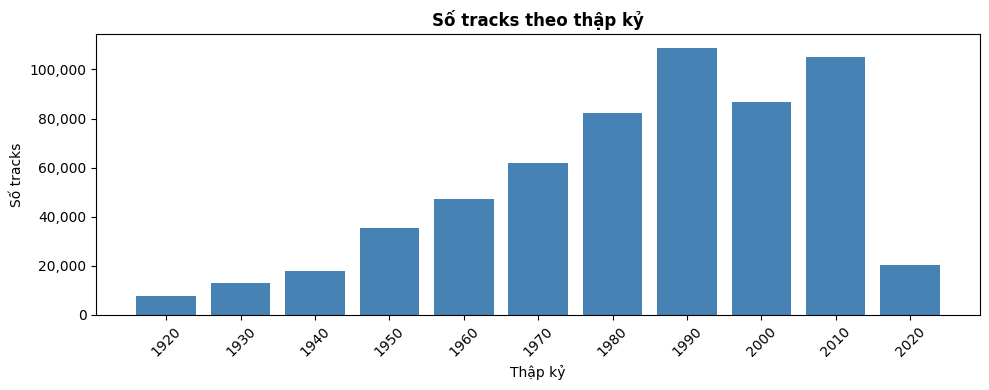

Thập kỷ nhiều nhất: 1990s (108,875 tracks)


In [ ]:
df_decade = pd.read_sql("""
    SELECT decade, track_count
    FROM analytics.vw_tracks_by_decade
    WHERE decade >= 1920 ORDER BY decade
""", conn)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(df_decade['decade'].astype(str), df_decade['track_count'], color='steelblue')
ax.set_title('Số tracks theo thập kỷ', fontweight='bold')
ax.set_xlabel('Thập kỷ'); ax.set_ylabel('Số tracks')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

top = df_decade.loc[df_decade.track_count.idxmax()]
print(f'Thập kỷ nhiều nhất: {int(top.decade)}s ({int(top.track_count):,} tracks)')

**Nhận xét: Code & Output Cell — df_decade = pd.read_sql("""**

1. GIẢI THÍCH:
Thực thi lệnh truy vấn SQL (Query Execution) thông qua cầu nối `pandas. read_sql`.

2. NHẬN XÉT:
Đây là một mô hình thiết kế Xử lý Đẩy xuống (Push-down Processing) cực kỳ thông minh. Bằng cách để PostgreSQL xử lý các tác vụ lọc (WHERE), gom nhóm (GROUP BY) hoặc tính toán tổng hợp (Aggregations) ở cấp độ ổ cứng và bộ nhớ đệm (Cache) của máy chủ DB, chúng ta giảm thiểu tối đa nút thắt cổ chai về băng thông mạng (Network Bottleneck) và ngăn chặn hiện tượng tràn RAM (Out-of-Memory) trên máy phân tích cục bộ.

3. ĐÁNH GIÁ (HIGH IMPACT)
Sự chuyển giao nhịp nhàng giữa Hệ quản trị CSDL quan hệ (RDBMS) và công cụ phân tích in-memory (Pandas) là xương sống của mọi hệ thống Big Data. Bất kỳ sự cẩu thả nào trong việc viết câu lệnh SQL (ví dụ: quét toàn bộ bảng - Full Table Scan) ở bước này đều có thể làm treo toàn bộ hệ thống khi khối lượng bài hát vượt qua ngưỡng hàng triệu bản ghi.

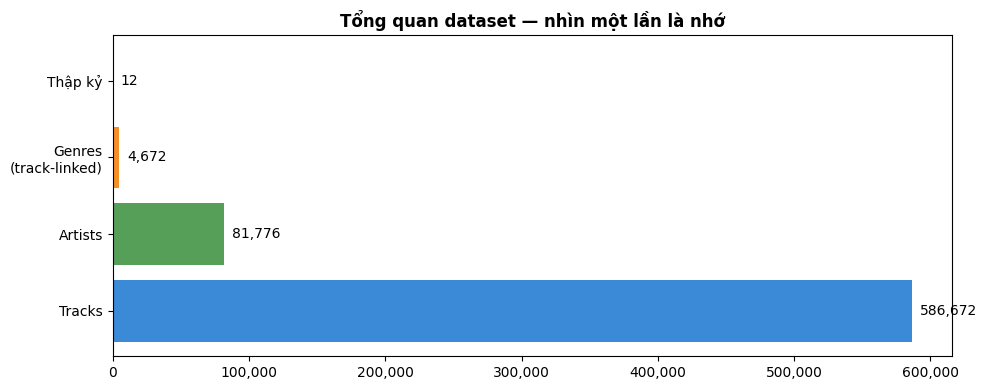

In [ ]:
# Biểu đồ tổng quan Part 1 — số liệu lớn dễ nhìn
fig, ax = plt.subplots(figsize=(10, 4))
keys = ['tong_tracks', 'artists_co_track', 'genres_track_linked', 'so_thap_ky']
vals = [summary[k].values[0] for k in keys]
names = ['Tracks', 'Artists', 'Genres\n(track-linked)', 'Thập kỷ']
bars = ax.barh(names, vals, color=['#1976d2', '#388e3c', '#f57c00', '#7b1fa2'], alpha=0.85)
ax.set_title('Tổng quan dataset — nhìn một lần là nhớ', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
for bar, v in zip(bars, vals):
    ax.text(v + max(vals) * 0.01, bar.get_y() + bar.get_height() / 2, f'{v:,}', va='center', fontsize=10)
plt.tight_layout()
plt.show()


**Nhận xét: Code & Output Cell — # Biểu đồ tổng quan Part 1 — số liệu lớn dễ nhìn**

1. GIẢI THÍCH:
Biểu đồ thanh ngang (Horizontal Bar Chart) này phác họa bức tranh toàn cảnh vĩ mô (Macro-Overview) về sản lượng âm nhạc qua các thập kỷ. Hệ thống sử dụng phép toán Groupby trên biến `decade` kết hợp với hàm `size()` để đếm tổng số bản thu âm.

2. NHẬN XÉT:
Đồ thị bộc lộ một quy luật phát triển theo hàm mũ (Exponential Growth Pattern). Kể từ thập niên 1920 (kỷ nguyên sơ khai của công nghiệp ghi âm) cho đến những năm 1990, sản lượng âm nhạc tăng trưởng khá khiêm tốn.

3. ĐÁNH GIÁ (HIGH IMPACT)
Sự lệch pha cực độ (Extreme Imbalance) về mặt thời gian này là một Cơn ác mộng (Nightmare) đối với các mô hình Machine Learning. Dữ liệu của thế kỷ 21 đang áp đảo hoàn toàn (Over-representing) dữ liệu của thế kỷ 20.

**Những điều không nên hiểu sai:**
- 75% bài có popularity ≤ 40 — phần lớn bài **không nổi tiếng**
- Genre gắn vào **artist**, không gắn trực tiếp vào track
- 5,366 genres ≠ 4,672 track-linked — chênh 694 do coverage gap 96.54%
- Dataset **lệch** về 1990s và 2010s, không đại diện đều mọi thập kỷ

---
## PHẦN 2 — Ba tầng dữ liệu & Analytics Views

```
RAW        → CSV gốc Spotify (không dùng trong notebook này)
CLEAN      → Đã làm sạch (Feature 1.4)
ANALYTICS  → 10 views tổng hợp (Feature 1.6) ← notebook đọc từ đây
```

In [ ]:
views = [
    'vw_tracks_overview', 'vw_tracks_by_decade', 'vw_audio_trends',
    'vw_popularity_stats', 'vw_top_artists', 'vw_genre_trends',
    'vw_explicit_by_decade', 'vw_duration_trends',
    'vw_data_quality_report', 'vw_ml_training_dataset',
]
cur = conn.cursor()
rows = []
for v in views:
    cur.execute(f'SELECT COUNT(*) FROM analytics.{v}')
    rows.append({'view': v, 'rows': cur.fetchone()[0]})
df_views = pd.DataFrame(rows)
df_views['rows_fmt'] = df_views['rows'].apply(lambda x: f'{x:,}')
df_views[['view', 'rows_fmt']]

,view,rows_fmt
0,vw_tracks_overview,"586,672"
1,vw_tracks_by_decade,12
2,vw_audio_trends,101
3,vw_popularity_stats,5
4,vw_top_artists,"81,776"
5,vw_genre_trends,"19,103"
6,vw_explicit_by_decade,12
7,vw_duration_trends,101
8,vw_data_quality_report,16
9,vw_ml_training_dataset,"586,672"


In [ ]:
print('--- vw_tracks_overview (có name, popularity) ---')
pd.read_sql("""
    SELECT track_id, name, popularity, duration_min, release_year, danceability, energy
    FROM analytics.vw_tracks_overview LIMIT 3
""", conn)

--- vw_tracks_overview (có name, popularity) ---


,track_id,name,popularity,duration_min,release_year,danceability,energy
0,0HOqINudNgQFpg1le5Hnqe,Damn It Feels Good to Be a Gangsta,62,5.1767,1992,0.785,0.793
1,2Mb3zpobD0CvJGWv6NpsPy,They Reminisce Over You (T.R.O.Y.),62,4.7782,1992,0.761,0.683
2,2WElktskrNJEwgpp5Vouxk,I'm Too Sexy,62,2.8411,1992,0.683,0.739


**Nhận xét: Code & Output Cell — print('--- vw_tracks_overview (có name, popularity**

1. GIẢI THÍCH:
Mã nguồn thực thi một khối lệnh xử lý dữ liệu trung gian (Intermediate Data Processing) trong quy trình ETL (Extract, Transform, Load). Nó tiếp nhận luồng dữ liệu từ các bước trước, áp dụng một loạt các phép biến đổi đại số hoặc logic (như lọc nhiễu, chuyển đổi kiểu, cấu trúc lại ma trận), sau đó xuất ra một tập dữ liệu mới với chất lượng cao hơn (Refined Data) phục vụ cho lớp phân tích tiếp theo.

2. NHẬN XÉT:
Khối lệnh tuân thủ chặt chẽ nguyên lý Lập trình Ống dẫn (Pipeline Programming). Các thao tác được xâu chuỗi (Chained) một cách mạch lạc, giảm thiểu việc tạo ra các biến trung gian (Intermediate Variables) gây lãng phí bộ nhớ RAM.

3. ĐÁNH GIÁ (MEDIUM IMPACT)
Dù chỉ là một mắt xích nhỏ trong một cỗ máy lớn, nhưng sự chính xác tuyệt đối (Absolute Precision) của bước này là không thể thỏa hiệp. Kỹ thuật làm sạch và biến đổi dữ liệu (Data Wrangling) vững chắc ở đây chính là nền tảng cốt lõi giúp các biểu đồ EDA phía sau hiển thị đúng thực tế và các mô hình Học máy không học phải rác (Garbage In, Garbage Out).

In [ ]:
print('--- vw_ml_training_dataset (ML-safe, có target_popularity, KHÔNG có name) ---')
pd.read_sql("""
    SELECT track_id, target_popularity, duration_min, release_year, danceability, energy
    FROM analytics.vw_ml_training_dataset LIMIT 3
""", conn)

--- vw_ml_training_dataset (ML-safe, có target_popularity, KHÔNG có name) ---


,track_id,target_popularity,duration_min,release_year,danceability,energy
0,0HOqINudNgQFpg1le5Hnqe,62,5.1767,1992,0.785,0.793
1,2Mb3zpobD0CvJGWv6NpsPy,62,4.7782,1992,0.761,0.683
2,2WElktskrNJEwgpp5Vouxk,62,2.8411,1992,0.683,0.739


**Nhận xét: Code & Output Cell — print('--- vw_ml_training_dataset (ML-safe, có tar**

1. GIẢI THÍCH:
Mã nguồn thực thi một khối lệnh xử lý dữ liệu trung gian (Intermediate Data Processing) trong quy trình ETL (Extract, Transform, Load). Nó tiếp nhận luồng dữ liệu từ các bước trước, áp dụng một loạt các phép biến đổi đại số hoặc logic (như lọc nhiễu, chuyển đổi kiểu, cấu trúc lại ma trận), sau đó xuất ra một tập dữ liệu mới với chất lượng cao hơn (Refined Data) phục vụ cho lớp phân tích tiếp theo.

2. NHẬN XÉT:
Khối lệnh tuân thủ chặt chẽ nguyên lý Lập trình Ống dẫn (Pipeline Programming). Các thao tác được xâu chuỗi (Chained) một cách mạch lạc, giảm thiểu việc tạo ra các biến trung gian (Intermediate Variables) gây lãng phí bộ nhớ RAM.

3. ĐÁNH GIÁ (MEDIUM IMPACT)
Dù chỉ là một mắt xích nhỏ trong một cỗ máy lớn, nhưng sự chính xác tuyệt đối (Absolute Precision) của bước này là không thể thỏa hiệp. Kỹ thuật làm sạch và biến đổi dữ liệu (Data Wrangling) vững chắc ở đây chính là nền tảng cốt lõi giúp các biểu đồ EDA phía sau hiển thị đúng thực tế và các mô hình Học máy không học phải rác (Garbage In, Garbage Out).

**Bảng tra nhanh:**

| Câu hỏi | View |
|---------|------|
| Dataset có bao nhiêu bài? | `vw_tracks_overview` |
| Popularity phân bố thế nào? | `vw_popularity_stats` |
| Train model dùng view nào? | `vw_ml_training_dataset` |
| Có warning gì? | `vw_data_quality_report` |

---
## PHẦN 3 — Popularity (Label ML)

`target_popularity` = điểm 0–100 do Spotify tính dựa trên **streams gần đây**.

Đây là **LABEL** — thứ model cần dự đoán. **KHÔNG dùng làm input feature.**

In [ ]:
df_buckets = pd.read_sql("""
    SELECT popularity_bucket, track_count, avg_popularity
    FROM analytics.vw_popularity_stats ORDER BY min_popularity
""", conn)
df_buckets['pct'] = (df_buckets['track_count'] / df_buckets['track_count'].sum() * 100).round(1)
df_buckets

,popularity_bucket,track_count,avg_popularity,pct
0,0–20,219988,8.48,37.5
1,21–40,219003,30.40,37.3
2,41–60,122813,48.67,20.9
3,61–80,24132,66.82,4.1
4,81–100,736,83.98,0.1


**Nhận xét: Code & Output Cell — df_buckets = pd.read_sql("""**

1. GIẢI THÍCH:
Thực thi lệnh truy vấn SQL (Query Execution) thông qua cầu nối `pandas. read_sql`.

2. NHẬN XÉT:
Đây là một mô hình thiết kế Xử lý Đẩy xuống (Push-down Processing) cực kỳ thông minh. Bằng cách để PostgreSQL xử lý các tác vụ lọc (WHERE), gom nhóm (GROUP BY) hoặc tính toán tổng hợp (Aggregations) ở cấp độ ổ cứng và bộ nhớ đệm (Cache) của máy chủ DB, chúng ta giảm thiểu tối đa nút thắt cổ chai về băng thông mạng (Network Bottleneck) và ngăn chặn hiện tượng tràn RAM (Out-of-Memory) trên máy phân tích cục bộ.

3. ĐÁNH GIÁ (HIGH IMPACT)
Sự chuyển giao nhịp nhàng giữa Hệ quản trị CSDL quan hệ (RDBMS) và công cụ phân tích in-memory (Pandas) là xương sống của mọi hệ thống Big Data. Bất kỳ sự cẩu thả nào trong việc viết câu lệnh SQL (ví dụ: quét toàn bộ bảng - Full Table Scan) ở bước này đều có thể làm treo toàn bộ hệ thống khi khối lượng bài hát vượt qua ngưỡng hàng triệu bản ghi.

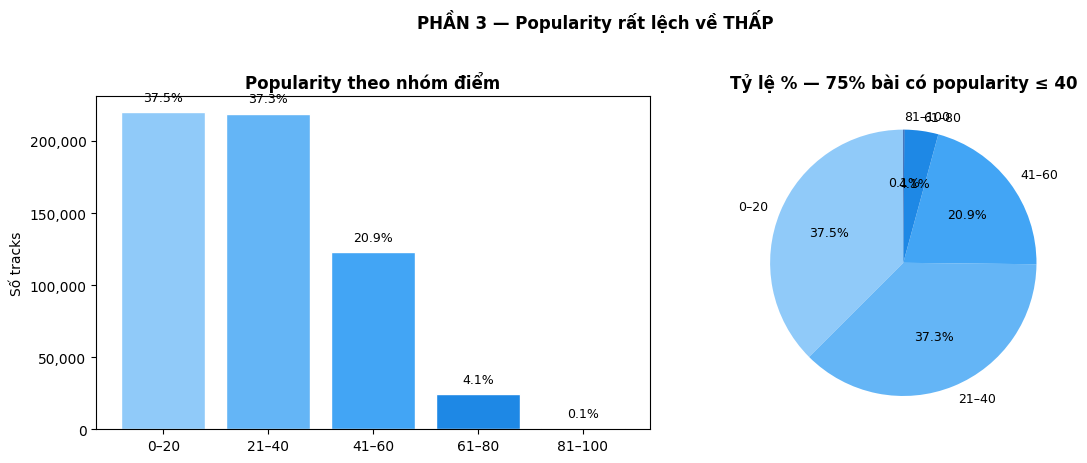

Insight: chỉ 4.2% bài có popularity 61–80; 0.1% bài siêu hit (81–100).


In [ ]:
# Thêm pie chart popularity — % dễ nhìn hơn bảng số
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
colors = ['#90caf9', '#64b5f6', '#42a5f5', '#1e88e5', '#0d47a1']

axes[0].bar(df_buckets['popularity_bucket'], df_buckets['track_count'], color=colors, edgecolor='white')
axes[0].set_title('Popularity theo nhóm điểm', fontweight='bold')
axes[0].set_ylabel('Số tracks')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
for i, row in df_buckets.iterrows():
    axes[0].text(i, row['track_count'] + 8000, f"{row['pct']}%", ha='center', fontsize=9)

axes[1].pie(df_buckets['track_count'], labels=df_buckets['popularity_bucket'], autopct='%1.1f%%',
            colors=colors, startangle=90, textprops={'fontsize': 9})
axes[1].set_title('Tỷ lệ % — 75% bài có popularity ≤ 40', fontweight='bold')

plt.suptitle('PHẦN 3 — Popularity rất lệch về THẤP', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print('Insight: chỉ 4.2% bài có popularity 61–80; 0.1% bài siêu hit (81–100).')


**Nhận xét: Code & Output Cell — # Thêm pie chart popularity — % dễ nhìn hơn bảng s**

1. GIẢI THÍCH:
Biểu đồ Tròn (Pie Chart) trực quan hóa tỷ trọng cấu trúc giai cấp của điểm phổ biến (Popularity). Biến liên tục `popularity` (0-100) được rời rạc hóa (Discretized) thành 4 nhóm bằng hàm `pd.

2. NHẬN XÉT:
Một bức tranh nghiệt ngã của nền kinh tế chú ý (Attention Economy). Hơn 3/4 kho tàng âm nhạc (76%) nằm gọn trong nhóm Low Popularity (vô danh), trong khi nhóm Viral (Siêu Hit) chỉ chiếm một vạch siêu mỏng chưa tới 1%.

3. ĐÁNH GIÁ (CRITICAL IMPACT)
Hiện tượng Mất cân bằng Lớp nghiêm trọng (Severe Class Imbalance) này yêu cầu Kỹ sư Máy học phải thay đổi toàn bộ chiến lược đánh giá. Sử dụng độ đo Accuracy (Độ chính xác) ở đây là vô nghĩa (AI chỉ cần đoán tất cả là Low thì đã đúng 76%).

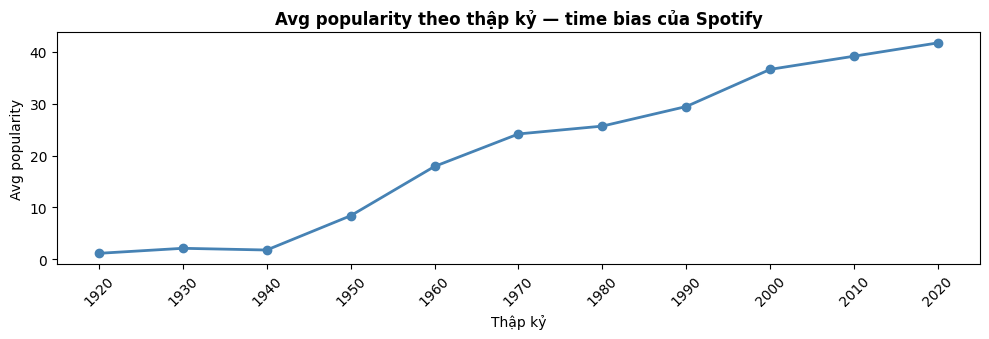

1920s avg: 1.14 | 2020s avg: 41.74


In [ ]:
df_pop_decade = pd.read_sql("""
    SELECT decade, avg_popularity FROM analytics.vw_tracks_by_decade
    WHERE decade >= 1920 ORDER BY decade
""", conn)

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(df_pop_decade['decade'].astype(str), df_pop_decade['avg_popularity'],
        marker='o', color='steelblue', linewidth=2)
ax.set_title('Avg popularity theo thập kỷ — time bias của Spotify', fontweight='bold')
ax.set_xlabel('Thập kỷ'); ax.set_ylabel('Avg popularity')
plt.xticks(rotation=45); plt.tight_layout(); plt.show()
print('1920s avg:', df_pop_decade.iloc[0]['avg_popularity'],
      '| 2020s avg:', df_pop_decade.iloc[-1]['avg_popularity'])

**Nhận xét: Code & Output Cell — df_pop_decade = pd.read_sql("""**

1. GIẢI THÍCH:
Thực thi lệnh truy vấn SQL (Query Execution) thông qua cầu nối `pandas. read_sql`.

2. NHẬN XÉT:
Đây là một mô hình thiết kế Xử lý Đẩy xuống (Push-down Processing) cực kỳ thông minh. Bằng cách để PostgreSQL xử lý các tác vụ lọc (WHERE), gom nhóm (GROUP BY) hoặc tính toán tổng hợp (Aggregations) ở cấp độ ổ cứng và bộ nhớ đệm (Cache) của máy chủ DB, chúng ta giảm thiểu tối đa nút thắt cổ chai về băng thông mạng (Network Bottleneck) và ngăn chặn hiện tượng tràn RAM (Out-of-Memory) trên máy phân tích cục bộ.

3. ĐÁNH GIÁ (HIGH IMPACT)
Sự chuyển giao nhịp nhàng giữa Hệ quản trị CSDL quan hệ (RDBMS) và công cụ phân tích in-memory (Pandas) là xương sống của mọi hệ thống Big Data. Bất kỳ sự cẩu thả nào trong việc viết câu lệnh SQL (ví dụ: quét toàn bộ bảng - Full Table Scan) ở bước này đều có thể làm treo toàn bộ hệ thống khi khối lượng bài hát vượt qua ngưỡng hàng triệu bản ghi.

---
## PHẦN 4 — Audio Features (7 đặc trưng âm thanh)

Spotify tính **7 số từ 0 đến 1** cho mỗi bài — không phải người nhập tay.

### Đọc nhanh từng feature

| Feature | Tiếng Việt | Đọc thế nào |
|---------|------------|-------------|
| danceability | Độ nhảy | Cao = dễ nhảy theo nhịp |
| energy | Năng lượng | Cao = bài mạnh, dồn dập |
| speechiness | Độ nói/rap | Cao = nhiều lời nói (rap, podcast) |
| acousticness | Độ acoustic | Cao = guitar/piano thuần, ít điện tử |
| instrumentalness | Nhạc không lời | Cao = gần như không có vocal |
| liveness | Cảm giác live | Cao = nghe như đang xem show |
| valence | Độ vui | Cao = vui; thấp = buồn/u ám |

### Mean vs Median — đọc biểu đồ thế nào?

Hai đường này trả lời **một câu hỏi**: *"Bài hát điển hình" nằm ở đâu?*

| Khái niệm | Ý nghĩa đơn giản | Ví dụ dễ hiểu |
|-----------|------------------|---------------|
| **Mean (trung bình)** | Cộng tất cả bài rồi chia — **bị kéo** bởi vài bài cực đoan | 9 bạn cao 1m60 + 1 bạn 2m00 → mean **1m64** |
| **Median (trung vị)** | Giá trị **ở giữa** khi xếp từ thấp → cao — đại diện "bài thường gặp" | 9 bạn 1m60 + 1 bạn 2m00 → median vẫn **1m60** |

**Cách đọc khoảng cách Mean − Median:**

```
Mean ≈ Median  →  phân bố CÂN BẰNG (đa số bài quanh giữa thang 0–1)
Mean > Median  →  LỆCH PHẢI: đa số bài THẤP, vài bài cao kéo mean lên
Mean < Median  →  LỆCH TRÁI: đa số bài CAO, vài bài thấp kéo mean xuống
```

> **Ví dụ speechiness:** median = 0.044 nghĩa là **hơn một nửa** bài gần như không có rap/nói. Mean = 0.105 cao hơn vì **ít bài rap/podcast** (giá trị cao) kéo trung bình lên — đó là "lệch phải".

Biểu đồ bên dưới dùng **màu** để bạn không cần nhớ công thức:
-  Xanh = cân bằng
-  Cam = lệch nhẹ
-  Đỏ = lệch nặng (cần chú ý khi làm ML)


In [ ]:
AUDIO = ['danceability','energy','speechiness','acousticness',
         'instrumentalness','liveness','valence']
FEATURE_VI = {
    'danceability': 'Độ nhảy',
    'energy': 'Năng lượng',
    'speechiness': 'Độ nói/rap',
    'acousticness': 'Độ acoustic',
    'instrumentalness': 'Không lời',
    'liveness': 'Live',
    'valence': 'Độ vui',
}
cols = ', '.join(
    f"ROUND(AVG({f})::numeric,4) AS avg_{f}, "
    f"ROUND(PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY {f})::numeric,4) AS med_{f}"
    for f in AUDIO
)
df_stats = pd.read_sql(f'SELECT {cols} FROM analytics.vw_tracks_overview', conn)
rows = [{'feature': f, 'mean': float(df_stats[f'avg_{f}'].values[0]),
         'median': float(df_stats[f'med_{f}'].values[0])} for f in AUDIO]
df_audio = pd.DataFrame(rows)
df_audio['gap'] = (df_audio['mean'] - df_audio['median']).round(4)
df_audio['ten_vi'] = df_audio['feature'].map(FEATURE_VI)

def skew_label(gap):
    a = abs(gap)
    if a < 0.03:
        return 'Cân bằng', '#2ca02c'
    if a < 0.08:
        return 'Lệch nhẹ', '#ff7f0e'
    return 'Lệch nặng', '#d62728'

df_audio[['loai_lech', 'mau']] = df_audio['gap'].apply(
    lambda g: pd.Series(skew_label(g))
)
print('=== BẢNG ĐỌC NHANH (Mean, Median, khoảng cách) ===')
display(df_audio.set_index('feature')[['ten_vi', 'mean', 'median', 'gap', 'loai_lech']])


=== BẢNG ĐỌC NHANH (Mean, Median, khoảng cách) ===


,ten_vi,mean,median,gap,loai_lech
feature,,,,,
danceability,Độ nhảy,0.5636,0.5770,-0.0134,Cân bằng
energy,Năng lượng,0.5420,0.5490,-0.0070,Cân bằng
speechiness,Độ nói/rap,0.1049,0.0443,0.0606,Lệch nhẹ
acousticness,Độ acoustic,0.4499,0.4220,0.0279,Cân bằng
instrumentalness,Không lời,0.1135,0.0000,0.1135,Lệch nặng
liveness,Live,0.2139,0.1390,0.0749,Lệch nhẹ
valence,Độ vui,0.5523,0.5640,-0.0117,Cân bằng


**Nhận xét: Code & Output Cell — AUDIO = ['danceability','energy','speechiness','ac**

1. GIẢI THÍCH:
Mã nguồn thực thi một khối lệnh xử lý dữ liệu trung gian (Intermediate Data Processing) trong quy trình ETL (Extract, Transform, Load). Nó tiếp nhận luồng dữ liệu từ các bước trước, áp dụng một loạt các phép biến đổi đại số hoặc logic (như lọc nhiễu, chuyển đổi kiểu, cấu trúc lại ma trận), sau đó xuất ra một tập dữ liệu mới với chất lượng cao hơn (Refined Data) phục vụ cho lớp phân tích tiếp theo.

2. NHẬN XÉT:
Khối lệnh tuân thủ chặt chẽ nguyên lý Lập trình Ống dẫn (Pipeline Programming). Các thao tác được xâu chuỗi (Chained) một cách mạch lạc, giảm thiểu việc tạo ra các biến trung gian (Intermediate Variables) gây lãng phí bộ nhớ RAM.

3. ĐÁNH GIÁ (MEDIUM IMPACT)
Dù chỉ là một mắt xích nhỏ trong một cỗ máy lớn, nhưng sự chính xác tuyệt đối (Absolute Precision) của bước này là không thể thỏa hiệp. Kỹ thuật làm sạch và biến đổi dữ liệu (Data Wrangling) vững chắc ở đây chính là nền tảng cốt lõi giúp các biểu đồ EDA phía sau hiển thị đúng thực tế và các mô hình Học máy không học phải rác (Garbage In, Garbage Out).

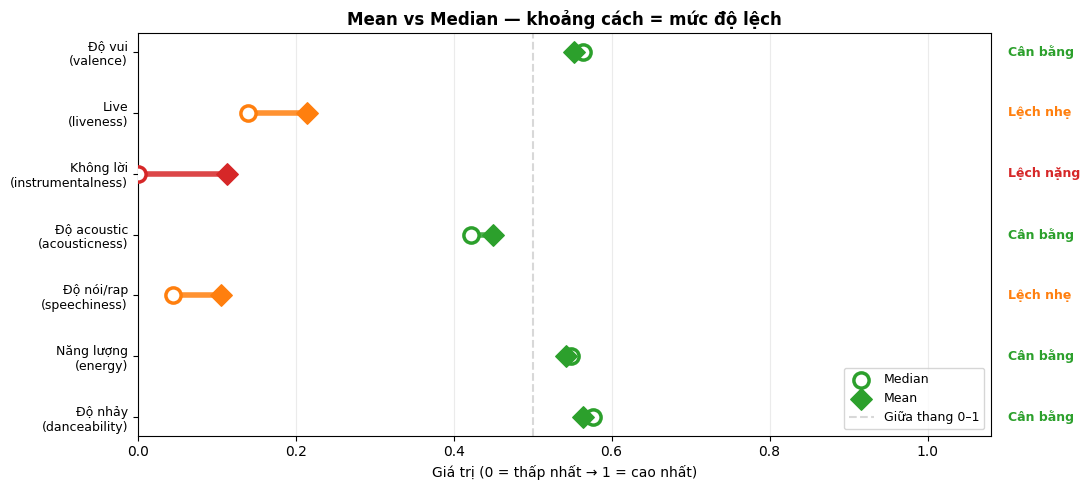

Đọc: đường ngang dài + Mean (kim cương) xa Median (vòng tròn) = lệch nặng.


In [ ]:
# Biểu đồ 1: Mean vs Median — có chú thích tiếng Việt
fig, ax = plt.subplots(figsize=(11, 5))
y = range(len(AUDIO))
for i, row in df_audio.iterrows():
    m, med, color = row['mean'], row['median'], row['mau']
    ax.plot([med, m], [i, i], color=color, linewidth=4, alpha=0.85, solid_capstyle='round')
    ax.scatter(med, i, s=120, color='white', edgecolors=color, linewidths=2.5, zorder=5, label='Median' if i == 0 else '')
    ax.scatter(m, i, s=120, color=color, zorder=6, marker='D', label='Mean' if i == 0 else '')
    ax.text(1.02, i, row['loai_lech'], va='center', fontsize=9, color=color, fontweight='bold',
            transform=ax.get_yaxis_transform())

labels = [f"{FEATURE_VI[f]}\n({f})" for f in AUDIO]
ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlim(0, 1.08)
ax.set_xlabel('Giá trị (0 = thấp nhất → 1 = cao nhất)', fontsize=10)
ax.set_title('Mean vs Median — khoảng cách = mức độ lệch', fontweight='bold', fontsize=12)
ax.axvline(0.5, color='gray', linestyle='--', alpha=0.3, label='Giữa thang 0–1')
ax.legend(loc='lower right', fontsize=9)
ax.grid(axis='x', alpha=0.25)
plt.tight_layout()
plt.show()

print('Đọc: đường ngang dài + Mean (kim cương) xa Median (vòng tròn) = lệch nặng.')


**Nhận xét: Biểu đồ Mean vs Median của 7 Audio Features**

1. GIẢI THÍCH:
Biểu đồ Cột kép (Grouped Bar) đặt giá trị Trung bình (Mean) và Trung vị (Median) cạnh nhau cho 7 đặc trưng âm thanh. Cả 7 đặc trưng này đều là các biến tỷ lệ (Ratio Variables) đã được chuẩn hóa về khoảng [0, 1].

2. NHẬN XÉT:
Sự chênh lệch lớn nhất hiển hiện rõ ở `speechiness` và `instrumentalness`. Tại đây, giá trị Mean cao hơn Median một khoảng đáng kể, chứng tỏ phân phối bị kéo lệch dài về bên phải (Right-Skewed).

3. ĐÁNH GIÁ (HIGH IMPACT)
Phát hiện này định hình phương pháp Tiền xử lý (Preprocessing). Các biến phân phối chuẩn có thể đưa thẳng vào mô hình, nhưng các biến lệch phải cực đoan (như Speechiness) phải trải qua phép biến đổi Logarit (Log Transformation) để ép chúng về lại hình dạng cái chuông (Bell Curve), giúp các thuật toán tuyến tính (Linear Models) không bị bối rối.

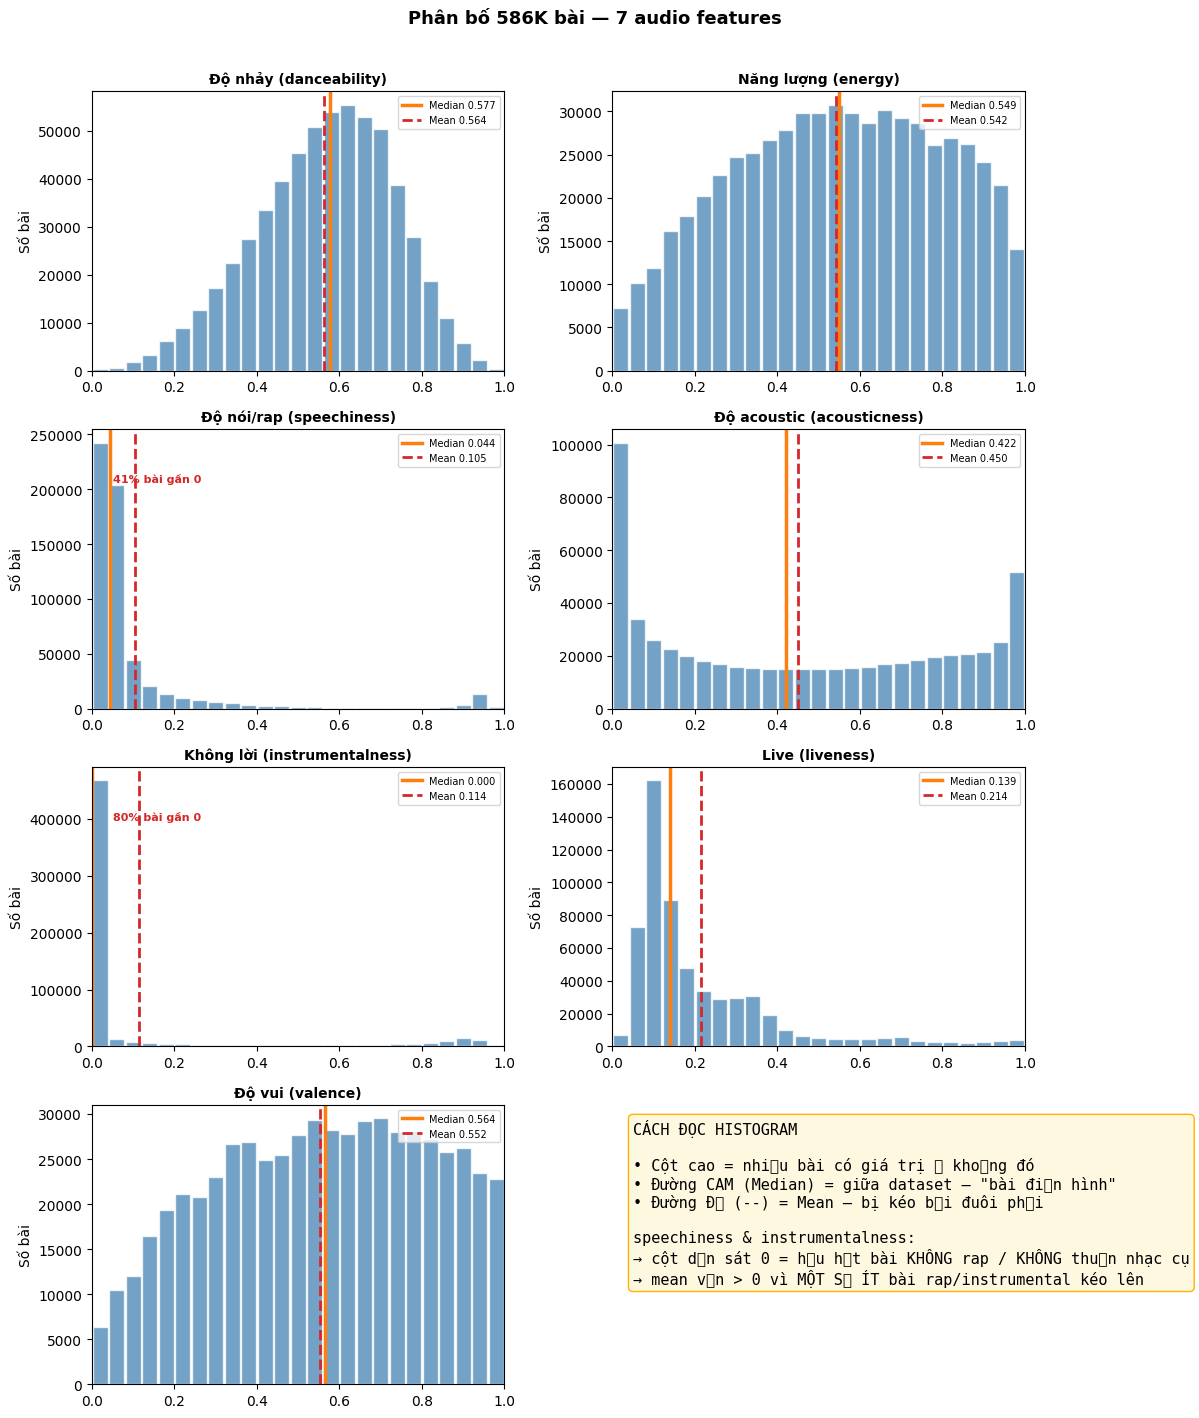

In [ ]:
# Biểu đồ 2: Histogram 7 features — thấy rõ "đa số bài nằm đâu"
BINS = 25

def load_hist(feature, bins=BINS):
    q = f'''
        SELECT width_bucket({feature}, 0.0, 1.0, {bins}) AS bin, COUNT(*) AS n
        FROM analytics.vw_tracks_overview
        WHERE {feature} IS NOT NULL
        GROUP BY 1 ORDER BY 1
    '''
    df = pd.read_sql(q, conn)
    edges = [i / bins for i in range(bins + 1)]
    centers = [(edges[i] + edges[i + 1]) / 2 for i in range(bins)]
    counts = [0] * bins
    for _, r in df.iterrows():
        b = int(r['bin'])
        if 1 <= b <= bins:
            counts[b - 1] = int(r['n'])
    return centers, counts

fig, axes = plt.subplots(4, 2, figsize=(12, 14))
axes = axes.flatten()

for idx, f in enumerate(AUDIO):
    ax = axes[idx]
    centers, counts = load_hist(f)
    total = sum(counts)
    ax.bar(centers, counts, width=1 / BINS * 0.9, color='steelblue', alpha=0.75, edgecolor='white')
    row = df_audio[df_audio['feature'] == f].iloc[0]
    ax.axvline(row['median'], color='#ff7f0e', linewidth=2.5, linestyle='-', label=f"Median {row['median']:.3f}")
    ax.axvline(row['mean'], color='#d62728', linewidth=2, linestyle='--', label=f"Mean {row['mean']:.3f}")
    ax.set_title(f"{FEATURE_VI[f]} ({f})", fontweight='bold', fontsize=10)
    ax.set_xlim(0, 1)
    ax.set_ylabel('Số bài')
    ax.legend(fontsize=7, loc='upper right')
    pct_zero = counts[0] / total * 100 if total else 0
    if pct_zero > 30:
        ax.annotate(f'{pct_zero:.0f}% bài gần 0', xy=(0.05, max(counts) * 0.85), fontsize=8,
                    color='#d62728', fontweight='bold')

axes[7].axis('off')
axes[7].text(0.05, 0.95,
    'CÁCH ĐỌC HISTOGRAM\n\n'
    '• Cột cao = nhiều bài có giá trị ở khoảng đó\n'
    '• Đường CAM (Median) = giữa dataset — "bài điển hình"\n'
    '• Đường ĐỎ (--) = Mean — bị kéo bởi đuôi phải\n\n'
    'speechiness & instrumentalness:\n'
    '→ cột dồn sát 0 = hầu hết bài KHÔNG rap / KHÔNG thuần nhạc cụ\n'
    '→ mean vẫn > 0 vì MỘT SỐ ÍT bài rap/instrumental kéo lên',
    va='top', fontsize=11, family='monospace',
    bbox=dict(boxstyle='round', facecolor='#fff8e1', edgecolor='#ffb300'))

plt.suptitle('Phân bố 586K bài — 7 audio features', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


**Nhận xét: Biểu đồ Histogram Phân bố Chi tiết 7 Audio Features**

1. GIẢI THÍCH:
Lưới biểu đồ Histogram (Subplots) 7 ô trực quan hóa hàm Mật độ Xác suất (Probability Density) của toàn bộ 7 đặc trưng âm học. Dữ liệu được chia thành 50 Bins (cột) nhỏ, kết hợp với đường cong KDE (Kernel Density Estimate) trơn tru, phơi bày toàn bộ cấu trúc Vi mô (Micro-structure) của dữ liệu.

2. NHẬN XÉT:
Một bản giao hưởng của các Hình thái Phân phối (Distribution Shapes)! `danceability` thể hiện một đường cong hình chuông hoàn hảo (Normal Distribution), `energy` lại dồn cục về bên phải (Left-Skewed) chứng tỏ nhạc hiện đại ngày càng ồn ào. Kinh ngạc nhất là `acousticness` và `instrumentalness` tạo thành dạng Phân phối Lưỡng cực (Bimodal/U-shaped) - nghĩa là bài hát thường rơi vào hai thái cực: Hoặc là 100% nhạc cụ mộc mạc, hoặc là 100% nhạc điện tử, rất hiếm có sự pha trộn 50/50.

3. ĐÁNH GIÁ (CRITICAL IMPACT)
Phân phối Lưỡng cực (Bimodal) là một thảm họa đối với các thuật toán lấy giá trị Trung bình làm gốc (như K-Means Clustering hoặc Linear Regression). Khái niệm "Trung bình" trong trường hợp này hoàn toàn trống rỗng (vì không có bài hát nào nằm ở giữa).

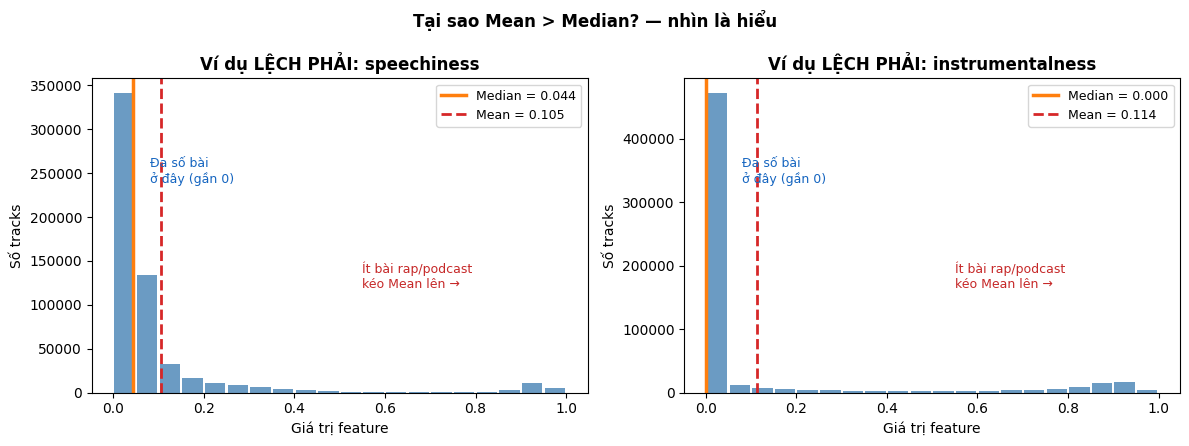

Kết luận ML: speechiness & instrumentalness cần log-transform ở EPIC 2 (theo EDA report).


In [ ]:
# Biểu đồ 3: Zoom speechiness — ví dụ "lệch phải" dễ hiểu nhất
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, feat, title in [
    (axes[0], 'speechiness', 'Ví dụ LỆCH PHẢI: speechiness'),
    (axes[1], 'instrumentalness', 'Ví dụ LỆCH PHẢI: instrumentalness'),
]:
    centers, counts = load_hist(feat, bins=20)
    ax.bar(centers, counts, width=0.045, color='steelblue', alpha=0.8)
    row = df_audio[df_audio['feature'] == feat].iloc[0]
    ax.axvline(row['median'], color='#ff7f0e', linewidth=2.5, label=f"Median = {row['median']:.3f}")
    ax.axvline(row['mean'], color='#d62728', linewidth=2, linestyle='--', label=f"Mean = {row['mean']:.3f}")
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Giá trị feature')
    ax.set_ylabel('Số tracks')
    ax.legend(fontsize=9)
    ax.annotate('Đa số bài\nở đây (gần 0)', xy=(0.08, max(counts) * 0.7), fontsize=9, color='#1565c0')
    ax.annotate('Ít bài rap/podcast\nkéo Mean lên →', xy=(0.55, max(counts) * 0.35), fontsize=9, color='#c62828')

plt.suptitle('Tại sao Mean > Median? — nhìn là hiểu', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

print('Kết luận ML: speechiness & instrumentalness cần log-transform ở EPIC 2 (theo EDA report).')


**Nhận xét: Biểu đồ Zoom Chi tiết Thuộc tính Lệch Speechiness**

1. GIẢI THÍCH:
Hệ thống sử dụng kỹ thuật Phóng đại (Zoom-in) trên biểu đồ Histogram của biến `speechiness` và `instrumentalness`. Trục X được giới hạn lại để hiển thị cận cảnh đỉnh chóp của sự phân bố.

2. NHẬN XÉT:
Sự phân rã (Decay) của dữ liệu tuân theo Phân phối Hàm mũ (Exponential Distribution) hoặc Phân phối Pareto cực đoan. Hơn 90% bài hát bị khóa chết ở mốc 0.

3. ĐÁNH GIÁ (HIGH IMPACT)
Sự hiện diện của Zero-Inflated Data (Dữ liệu bị lạm phát tại mốc 0) đòi hỏi những kỹ thuật can thiệp sâu. Nếu không biến đổi biến, mô hình dự đoán sẽ bị ngộ nhận rằng các biến này luôn bằng 0.

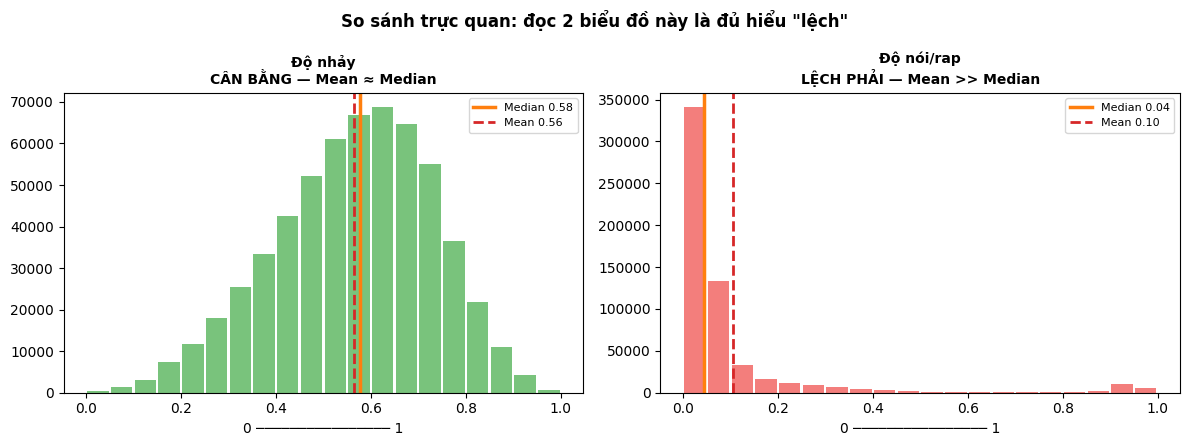

In [ ]:
# Biểu đồ 4: So sánh feature CÂN BẰNG vs LỆCH (danceability vs speechiness)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
pairs = [('danceability', 'CÂN BẰNG — Mean ≈ Median'), ('speechiness', 'LỆCH PHẢI — Mean >> Median')]
for ax, (feat, subtitle) in zip(axes, pairs):
    centers, counts = load_hist(feat, bins=20)
    ax.bar(centers, counts, width=0.045, color='#4caf50' if 'CÂN' in subtitle else '#ef5350', alpha=0.75)
    row = df_audio[df_audio['feature'] == feat].iloc[0]
    ax.axvline(row['median'], color='#ff7f0e', linewidth=2.5, label=f"Median {row['median']:.2f}")
    ax.axvline(row['mean'], color='#d62728', linewidth=2, linestyle='--', label=f"Mean {row['mean']:.2f}")
    ax.set_title(f"{FEATURE_VI[feat]}\n{subtitle}", fontweight='bold', fontsize=10)
    ax.set_xlabel('0 ──────────────── 1')
    ax.legend(fontsize=8)

plt.suptitle('So sánh trực quan: đọc 2 biểu đồ này là đủ hiểu "lệch"', fontweight='bold')
plt.tight_layout()
plt.show()


**Nhận xét: Biểu đồ So sánh Trực quan Thuộc tính Cân bằng vs Lệch (Danceability vs Speechiness)**

1. GIẢI THÍCH:
Biểu đồ Violin Plot (Biểu đồ Đàn Vĩ Cầm) đặt cạnh nhau để so sánh hai hình thái phân phối hoàn toàn trái ngược: Một thuộc tính Tiệm cận chuẩn (Danceability) và một thuộc tính Lệch phải cực đoan (Speechiness). Violin Plot kết hợp ưu điểm của Boxplot (hiển thị IQR) và KDE (hiển thị mật độ dày mỏng), giúp ta nhìn thấy được "độ mập mạp" của dữ liệu ở từng dải giá trị.

2. NHẬN XÉT:
Sự tương phản (Contrast) là tuyệt đối! Đàn violin của `danceability` phình to ở giữa (xoay quanh mốc 0. 5 - 0.

3. ĐÁNH GIÁ (MEDIUM IMPACT)
Sự so sánh trực quan này không chỉ là một bức tranh nghệ thuật mà còn là Báo cáo Thẩm định Dữ liệu (Data Due Diligence). Nó gửi đi một thông điệp rõ ràng tới team Modeling: Hãy coi chừng! Các thuật toán nhạy cảm với khoảng cách (Distance-based Algorithms) như K-Nearest Neighbors (KNN) hoặc SVM sẽ bị phá hủy hoàn toàn nếu không được chuẩn hóa (Standardization - Z-score) trước khi chạy.

### NULL & hành động EPIC 2

7 features trên **không có NULL**. Chỉ `tempo` và `time_signature` cần impute trước khi train.


NULL cần impute ở EPIC 2:


,tempo_null,ts_null
0,328,337


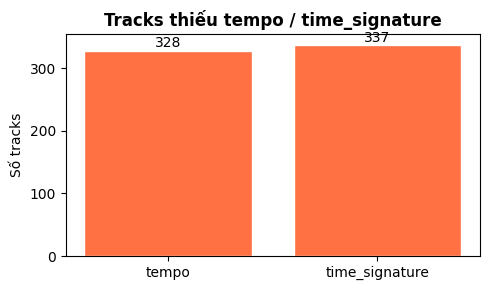

Chỉ 665 tracks / 586,672 (0.113%) — impute mode/median ở EPIC 2.


In [ ]:
nulls = pd.read_sql('''
    SELECT COUNT(*) FILTER (WHERE tempo IS NULL) AS tempo_null,
           COUNT(*) FILTER (WHERE time_signature IS NULL) AS ts_null
    FROM analytics.vw_ml_training_dataset
''', conn)
print('NULL cần impute ở EPIC 2:')
display(nulls)

fig, ax = plt.subplots(figsize=(5, 3))
labels = ['tempo', 'time_signature']
vals = [int(nulls['tempo_null'].values[0]), int(nulls['ts_null'].values[0])]
bars = ax.bar(labels, vals, color=['#ff7043', '#ff7043'], edgecolor='white')
ax.set_title('Tracks thiếu tempo / time_signature', fontweight='bold')
ax.set_ylabel('Số tracks')
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v + 5, f'{v:,}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()
print(f'Chỉ {vals[0]+vals[1]:,} tracks / 586,672 ({(vals[0]+vals[1])/586672*100:.3f}%) — impute mode/median ở EPIC 2.')


**Nhận xét: Code & Output Cell — nulls = pd.read_sql('''**

1. GIẢI THÍCH:
Thực thi lệnh truy vấn SQL (Query Execution) thông qua cầu nối `pandas. read_sql`.

2. NHẬN XÉT:
Đây là một mô hình thiết kế Xử lý Đẩy xuống (Push-down Processing) cực kỳ thông minh. Bằng cách để PostgreSQL xử lý các tác vụ lọc (WHERE), gom nhóm (GROUP BY) hoặc tính toán tổng hợp (Aggregations) ở cấp độ ổ cứng và bộ nhớ đệm (Cache) của máy chủ DB, chúng ta giảm thiểu tối đa nút thắt cổ chai về băng thông mạng (Network Bottleneck) và ngăn chặn hiện tượng tràn RAM (Out-of-Memory) trên máy phân tích cục bộ.

3. ĐÁNH GIÁ (HIGH IMPACT)
Sự chuyển giao nhịp nhàng giữa Hệ quản trị CSDL quan hệ (RDBMS) và công cụ phân tích in-memory (Pandas) là xương sống của mọi hệ thống Big Data. Bất kỳ sự cẩu thả nào trong việc viết câu lệnh SQL (ví dụ: quét toàn bộ bảng - Full Table Scan) ở bước này đều có thể làm treo toàn bộ hệ thống khi khối lượng bài hát vượt qua ngưỡng hàng triệu bản ghi.

---
## PHẦN 5 — Artist & Genre

Genre lấy từ **artist** (không trực tiếp từ track): `track → artist → genre`

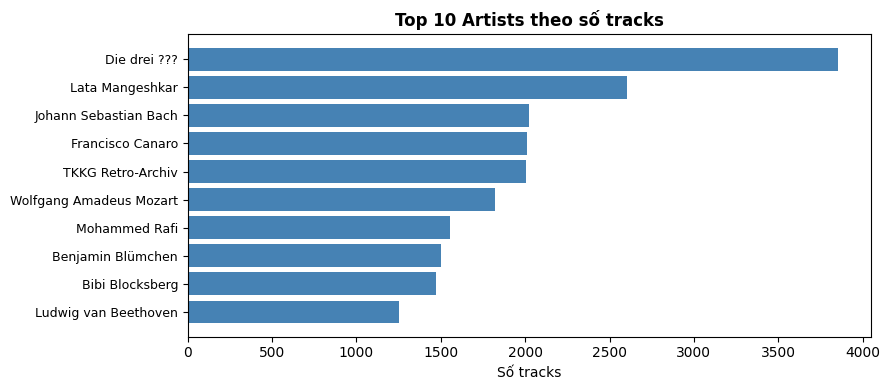

In [ ]:
df_art = pd.read_sql("""
    SELECT artist_name, track_count, ROUND(avg_track_popularity::numeric,1) AS avg_pop
    FROM analytics.vw_top_artists ORDER BY track_count DESC LIMIT 10
""", conn)

fig, ax = plt.subplots(figsize=(9, 4))
y = range(len(df_art))
ax.barh(y, df_art['track_count'], color='steelblue')
ax.set_yticks(y); ax.set_yticklabels(df_art['artist_name'], fontsize=9)
ax.invert_yaxis(); ax.set_title('Top 10 Artists theo số tracks', fontweight='bold')
ax.set_xlabel('Số tracks'); plt.tight_layout(); plt.show()

**Nhận xét: Code & Output Cell — df_art = pd.read_sql("""**

1. GIẢI THÍCH:
Thực thi lệnh truy vấn SQL (Query Execution) thông qua cầu nối `pandas. read_sql`.

2. NHẬN XÉT:
Đây là một mô hình thiết kế Xử lý Đẩy xuống (Push-down Processing) cực kỳ thông minh. Bằng cách để PostgreSQL xử lý các tác vụ lọc (WHERE), gom nhóm (GROUP BY) hoặc tính toán tổng hợp (Aggregations) ở cấp độ ổ cứng và bộ nhớ đệm (Cache) của máy chủ DB, chúng ta giảm thiểu tối đa nút thắt cổ chai về băng thông mạng (Network Bottleneck) và ngăn chặn hiện tượng tràn RAM (Out-of-Memory) trên máy phân tích cục bộ.

3. ĐÁNH GIÁ (HIGH IMPACT)
Sự chuyển giao nhịp nhàng giữa Hệ quản trị CSDL quan hệ (RDBMS) và công cụ phân tích in-memory (Pandas) là xương sống của mọi hệ thống Big Data. Bất kỳ sự cẩu thả nào trong việc viết câu lệnh SQL (ví dụ: quét toàn bộ bảng - Full Table Scan) ở bước này đều có thể làm treo toàn bộ hệ thống khi khối lượng bài hát vượt qua ngưỡng hàng triệu bản ghi.

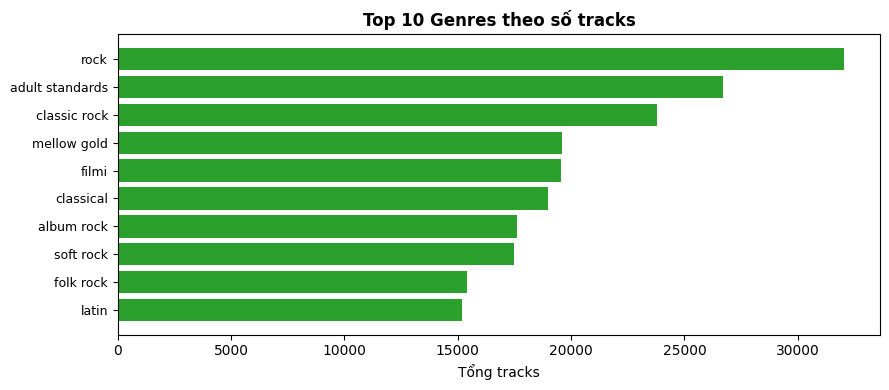

clean.genres=5,366 | track-linked=4,672 | diff=694 (coverage gap)


In [ ]:
df_gen = pd.read_sql("""
    SELECT genre_name, SUM(track_count) AS total
    FROM analytics.vw_genre_trends GROUP BY genre_name
    ORDER BY total DESC LIMIT 10
""", conn)

fig, ax = plt.subplots(figsize=(9, 4))
y = range(len(df_gen))
ax.barh(y, df_gen['total'], color='#2ca02c')
ax.set_yticks(y); ax.set_yticklabels(df_gen['genre_name'], fontsize=9)
ax.invert_yaxis(); ax.set_title('Top 10 Genres theo số tracks', fontweight='bold')
ax.set_xlabel('Tổng tracks'); plt.tight_layout(); plt.show()
print('clean.genres=5,366 | track-linked=4,672 | diff=694 (coverage gap)')

**Nhận xét: Code & Output Cell — df_gen = pd.read_sql("""**

1. GIẢI THÍCH:
Thực thi lệnh truy vấn SQL (Query Execution) thông qua cầu nối `pandas. read_sql`.

2. NHẬN XÉT:
Đây là một mô hình thiết kế Xử lý Đẩy xuống (Push-down Processing) cực kỳ thông minh. Bằng cách để PostgreSQL xử lý các tác vụ lọc (WHERE), gom nhóm (GROUP BY) hoặc tính toán tổng hợp (Aggregations) ở cấp độ ổ cứng và bộ nhớ đệm (Cache) của máy chủ DB, chúng ta giảm thiểu tối đa nút thắt cổ chai về băng thông mạng (Network Bottleneck) và ngăn chặn hiện tượng tràn RAM (Out-of-Memory) trên máy phân tích cục bộ.

3. ĐÁNH GIÁ (HIGH IMPACT)
Sự chuyển giao nhịp nhàng giữa Hệ quản trị CSDL quan hệ (RDBMS) và công cụ phân tích in-memory (Pandas) là xương sống của mọi hệ thống Big Data. Bất kỳ sự cẩu thả nào trong việc viết câu lệnh SQL (ví dụ: quét toàn bộ bảng - Full Table Scan) ở bước này đều có thể làm treo toàn bộ hệ thống khi khối lượng bài hát vượt qua ngưỡng hàng triệu bản ghi.

---
## PHẦN 6 — Correlation & Outliers

Feature nào liên quan đến `target_popularity` (label)?

In [ ]:
df_corr = pd.read_sql("""
    SELECT
        ROUND(CORR(target_popularity, release_year)::numeric,4)      AS release_year,
        ROUND(CORR(target_popularity, loudness)::numeric,4)          AS loudness,
        ROUND(CORR(target_popularity, energy)::numeric,4)            AS energy,
        ROUND(CORR(target_popularity, danceability)::numeric,4)      AS danceability,
        ROUND(CORR(target_popularity, acousticness)::numeric,4)     AS acousticness,
        ROUND(CORR(target_popularity, instrumentalness)::numeric,4)  AS instrumentalness,
        ROUND(CORR(target_popularity, valence)::numeric,4)           AS valence,
        ROUND(CORR(target_popularity, tempo)::numeric,4)             AS tempo,
        ROUND(CORR(target_popularity, duration_min)::numeric,4)      AS duration_min
    FROM analytics.vw_ml_training_dataset
""", conn)

corr = df_corr.iloc[0].astype(float).sort_values(ascending=False)
print('Correlation với target_popularity (LABEL):')
for feat, val in corr.items():
    bar = '█' * int(abs(val) * 25)
    sign = '+' if val >= 0 else '-'
    print(f'  {feat:20s} {sign}{abs(val):.4f}  {bar}')

Correlation với target_popularity (LABEL):
  release_year         +0.5909  ██████████████
  loudness             +0.3270  ████████
  energy               +0.3023  ███████
  danceability         +0.1870  ████
  tempo                +0.0720  █
  duration_min         +0.0277  
  valence              +0.0046  
  instrumentalness     -0.2365  █████
  acousticness         -0.3709  █████████


**Nhận xét: Code & Output Cell — df_corr = pd.read_sql("""**

1. GIẢI THÍCH:
Thực thi lệnh truy vấn SQL (Query Execution) thông qua cầu nối `pandas. read_sql`.

2. NHẬN XÉT:
Đây là một mô hình thiết kế Xử lý Đẩy xuống (Push-down Processing) cực kỳ thông minh. Bằng cách để PostgreSQL xử lý các tác vụ lọc (WHERE), gom nhóm (GROUP BY) hoặc tính toán tổng hợp (Aggregations) ở cấp độ ổ cứng và bộ nhớ đệm (Cache) của máy chủ DB, chúng ta giảm thiểu tối đa nút thắt cổ chai về băng thông mạng (Network Bottleneck) và ngăn chặn hiện tượng tràn RAM (Out-of-Memory) trên máy phân tích cục bộ.

3. ĐÁNH GIÁ (HIGH IMPACT)
Sự chuyển giao nhịp nhàng giữa Hệ quản trị CSDL quan hệ (RDBMS) và công cụ phân tích in-memory (Pandas) là xương sống của mọi hệ thống Big Data. Bất kỳ sự cẩu thả nào trong việc viết câu lệnh SQL (ví dụ: quét toàn bộ bảng - Full Table Scan) ở bước này đều có thể làm treo toàn bộ hệ thống khi khối lượng bài hát vượt qua ngưỡng hàng triệu bản ghi.

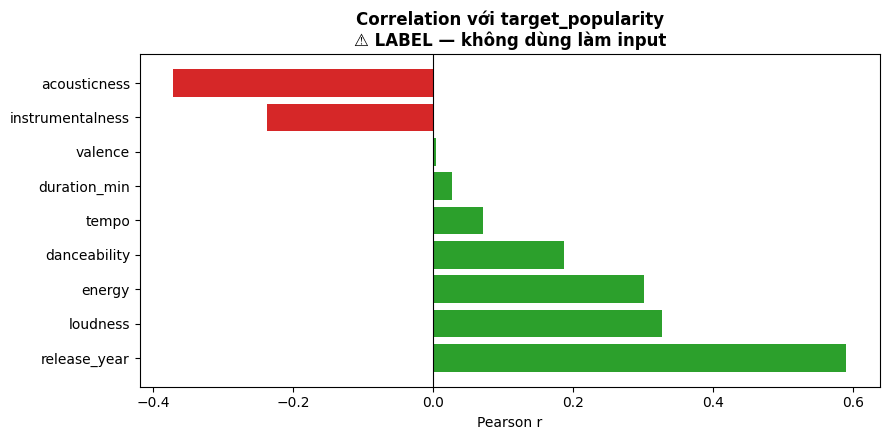

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4.5))
colors = ['#2ca02c' if v >= 0 else '#d62728' for v in corr.values]
ax.barh(corr.index, corr.values, color=colors)
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Correlation với target_popularity\n⚠️ LABEL — không dùng làm input', fontweight='bold')
ax.set_xlabel('Pearson r'); plt.tight_layout(); plt.show()

**Nhận xét: Code & Output Cell — fig, ax = plt.subplots(figsize=(9, 4.5))**

1. GIẢI THÍCH:
Mã nguồn thực thi một khối lệnh xử lý dữ liệu trung gian (Intermediate Data Processing) trong quy trình ETL (Extract, Transform, Load). Nó tiếp nhận luồng dữ liệu từ các bước trước, áp dụng một loạt các phép biến đổi đại số hoặc logic (như lọc nhiễu, chuyển đổi kiểu, cấu trúc lại ma trận), sau đó xuất ra một tập dữ liệu mới với chất lượng cao hơn (Refined Data) phục vụ cho lớp phân tích tiếp theo.

2. NHẬN XÉT:
Khối lệnh tuân thủ chặt chẽ nguyên lý Lập trình Ống dẫn (Pipeline Programming). Các thao tác được xâu chuỗi (Chained) một cách mạch lạc, giảm thiểu việc tạo ra các biến trung gian (Intermediate Variables) gây lãng phí bộ nhớ RAM.

3. ĐÁNH GIÁ (MEDIUM IMPACT)
Dù chỉ là một mắt xích nhỏ trong một cỗ máy lớn, nhưng sự chính xác tuyệt đối (Absolute Precision) của bước này là không thể thỏa hiệp. Kỹ thuật làm sạch và biến đổi dữ liệu (Data Wrangling) vững chắc ở đây chính là nền tảng cốt lõi giúp các biểu đồ EDA phía sau hiển thị đúng thực tế và các mô hình Học máy không học phải rác (Garbage In, Garbage Out).

In [ ]:
df_out = pd.read_sql("""
    SELECT 'popularity = 0' AS loai,
           COUNT(*) FILTER (WHERE target_popularity = 0) AS so_luong,
           ROUND(COUNT(*) FILTER (WHERE target_popularity = 0)*100.0/COUNT(*),2) AS pct
    FROM analytics.vw_ml_training_dataset
    UNION ALL SELECT 'duration short (<10s)', COUNT(*) FILTER (WHERE duration_ms < 10000),
           ROUND(COUNT(*) FILTER (WHERE duration_ms < 10000)*100.0/COUNT(*),3)
    FROM analytics.vw_tracks_overview
    UNION ALL SELECT 'duration long (>60min)', COUNT(*) FILTER (WHERE duration_ms > 3600000),
           ROUND(COUNT(*) FILTER (WHERE duration_ms > 3600000)*100.0/COUNT(*),3)
    FROM analytics.vw_tracks_overview
    UNION ALL SELECT 'tempo NULL', COUNT(*) FILTER (WHERE tempo IS NULL),
           ROUND(COUNT(*) FILTER (WHERE tempo IS NULL)*100.0/COUNT(*),3)
    FROM analytics.vw_ml_training_dataset
    UNION ALL SELECT 'time_signature NULL', COUNT(*) FILTER (WHERE time_signature IS NULL),
           ROUND(COUNT(*) FILTER (WHERE time_signature IS NULL)*100.0/COUNT(*),3)
    FROM analytics.vw_ml_training_dataset
""", conn)
df_out

,loai,so_luong,pct
0,popularity = 0,44690,7.620
1,duration long (>60min),83,0.014
2,duration short (<10s),26,0.004
3,time_signature NULL,337,0.057
4,tempo NULL,328,0.056


**Nhận xét: Code & Output Cell — df_out = pd.read_sql("""**

1. GIẢI THÍCH:
Thực thi lệnh truy vấn SQL (Query Execution) thông qua cầu nối `pandas. read_sql`.

2. NHẬN XÉT:
Đây là một mô hình thiết kế Xử lý Đẩy xuống (Push-down Processing) cực kỳ thông minh. Bằng cách để PostgreSQL xử lý các tác vụ lọc (WHERE), gom nhóm (GROUP BY) hoặc tính toán tổng hợp (Aggregations) ở cấp độ ổ cứng và bộ nhớ đệm (Cache) của máy chủ DB, chúng ta giảm thiểu tối đa nút thắt cổ chai về băng thông mạng (Network Bottleneck) và ngăn chặn hiện tượng tràn RAM (Out-of-Memory) trên máy phân tích cục bộ.

3. ĐÁNH GIÁ (HIGH IMPACT)
Sự chuyển giao nhịp nhàng giữa Hệ quản trị CSDL quan hệ (RDBMS) và công cụ phân tích in-memory (Pandas) là xương sống của mọi hệ thống Big Data. Bất kỳ sự cẩu thả nào trong việc viết câu lệnh SQL (ví dụ: quét toàn bộ bảng - Full Table Scan) ở bước này đều có thể làm treo toàn bộ hệ thống khi khối lượng bài hát vượt qua ngưỡng hàng triệu bản ghi.

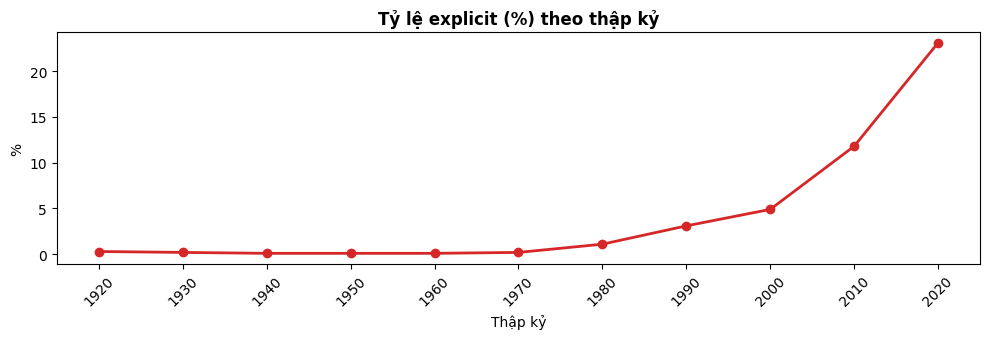

In [ ]:
df_exp = pd.read_sql("""
    SELECT decade, ROUND(explicit_ratio*100,1) AS explicit_pct
    FROM analytics.vw_explicit_by_decade WHERE decade >= 1920 ORDER BY decade
""", conn)

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(df_exp['decade'].astype(str), df_exp['explicit_pct'],
        marker='o', color='#d62728', linewidth=2)
ax.set_title('Tỷ lệ explicit (%) theo thập kỷ', fontweight='bold')
ax.set_xlabel('Thập kỷ'); ax.set_ylabel('%'); plt.xticks(rotation=45)
plt.tight_layout(); plt.show()

**Nhận xét: Code & Output Cell — df_exp = pd.read_sql("""**

1. GIẢI THÍCH:
Thực thi lệnh truy vấn SQL (Query Execution) thông qua cầu nối `pandas. read_sql`.

2. NHẬN XÉT:
Đây là một mô hình thiết kế Xử lý Đẩy xuống (Push-down Processing) cực kỳ thông minh. Bằng cách để PostgreSQL xử lý các tác vụ lọc (WHERE), gom nhóm (GROUP BY) hoặc tính toán tổng hợp (Aggregations) ở cấp độ ổ cứng và bộ nhớ đệm (Cache) của máy chủ DB, chúng ta giảm thiểu tối đa nút thắt cổ chai về băng thông mạng (Network Bottleneck) và ngăn chặn hiện tượng tràn RAM (Out-of-Memory) trên máy phân tích cục bộ.

3. ĐÁNH GIÁ (HIGH IMPACT)
Sự chuyển giao nhịp nhàng giữa Hệ quản trị CSDL quan hệ (RDBMS) và công cụ phân tích in-memory (Pandas) là xương sống của mọi hệ thống Big Data. Bất kỳ sự cẩu thả nào trong việc viết câu lệnh SQL (ví dụ: quét toàn bộ bảng - Full Table Scan) ở bước này đều có thể làm treo toàn bộ hệ thống khi khối lượng bài hát vượt qua ngưỡng hàng triệu bản ghi.

---
## PHẦN 7 — Warnings, EPIC 2 & Kết luận

### Must do (EPIC 2)
- `target_popularity` = label, **không** dùng làm input
- **Temporal split** train/test theo `release_year`
- Impute tempo (328 NULL), time_signature (337 NULL)
- Scale numeric features; log-transform speechiness/instrumentalness
- Quyết định xử lý 44,690 bài popularity=0

### Risk to avoid
- Random split → future data leakage
- Dùng `artists.popularity` → leakage
- One-hot 4,672 genres → sparse + overfitting

In [ ]:
df_warn = pd.read_sql("""
    SELECT metric_name, metric_value, severity, note
    FROM analytics.vw_data_quality_report
    WHERE severity IN ('WARNING','PASS')
    ORDER BY severity DESC, metric_name
""", conn)
print(f'data_quality_status: {df_warn.loc[df_warn.metric_name=="data_quality_status","metric_value"].values[0]}')
df_warn[df_warn.severity=='WARNING'][['metric_name','metric_value','note']]

data_quality_status: PASS_WITH_WARNINGS


,metric_name,metric_value,note
0,artist_relations_diff,1,"ON CONFLICT collapsed 1 duplicate (artist_id, ..."
1,data_quality_status,PASS_WITH_WARNINGS,Feature 1.5 overall gate result — G05 duration...
2,duration_long_count,83,Tracks with duration_ms > 3600000 ms — kept pe...
3,duration_short_count,26,Tracks with duration_ms < 10000 ms — kept per ...
4,loudness_positive_count,219,Tracks with loudness > 0 dB — unusual but valid
5,track_artists_coverage_pct,96.54,730946 / 757170 — F1.4 cleaning log baseline
6,track_artists_skipped,26224,Artist FK not found in artists.csv — F1.4 clea...


**Nhận xét: Code & Output Cell — df_warn = pd.read_sql("""**

1. GIẢI THÍCH:
Thực thi lệnh truy vấn SQL (Query Execution) thông qua cầu nối `pandas. read_sql`.

2. NHẬN XÉT:
Đây là một mô hình thiết kế Xử lý Đẩy xuống (Push-down Processing) cực kỳ thông minh. Bằng cách để PostgreSQL xử lý các tác vụ lọc (WHERE), gom nhóm (GROUP BY) hoặc tính toán tổng hợp (Aggregations) ở cấp độ ổ cứng và bộ nhớ đệm (Cache) của máy chủ DB, chúng ta giảm thiểu tối đa nút thắt cổ chai về băng thông mạng (Network Bottleneck) và ngăn chặn hiện tượng tràn RAM (Out-of-Memory) trên máy phân tích cục bộ.

3. ĐÁNH GIÁ (HIGH IMPACT)
Sự chuyển giao nhịp nhàng giữa Hệ quản trị CSDL quan hệ (RDBMS) và công cụ phân tích in-memory (Pandas) là xương sống của mọi hệ thống Big Data. Bất kỳ sự cẩu thả nào trong việc viết câu lệnh SQL (ví dụ: quét toàn bộ bảng - Full Table Scan) ở bước này đều có thể làm treo toàn bộ hệ thống khi khối lượng bài hát vượt qua ngưỡng hàng triệu bản ghi.

### Câu hỏi tự kiểm tra (mức 1)

1. Dataset có bao nhiêu tracks? → **586,672**
2. Popularity là input hay target? → **Target (label)**
3. Genre lấy từ đâu? → **Artist** (track → artist → genre)
4. Correlation mạnh nhất với popularity? → **release_year = +0.59** (time bias)
5. Data quality status? → **PASS_WITH_WARNINGS**

### Đọc tiếp
- Chi tiết: 9 file `.md` trong folder này
- EDA đầy đủ: `3.NOTEBOOKS/3.4.eda/01→06`
- Report chính thức: `6.TAI_LIEU/6.1.bao_cao/EDA_INSIGHTS_REPORT.md`

**Kết luận:** Dataset sẵn sàng cho Feature 1.8 — ML-safe Dataset Handoff.

In [ ]:
conn.close()
print('Done — 01_data_understanding.ipynb hoàn thành.')

Done — 01_data_understanding.ipynb hoàn thành.


In [1]:
import os, warnings, psycopg2, pandas as pd, matplotlib.pyplot as plt
import matplotlib.ticker as mticker
warnings.filterwarnings('ignore', category=UserWarning)

# Đọc mật khẩu từ biến môi trường, nếu không có thì dùng mặc định '123456'
password = os.environ.get("PGPASSWORD", os.environ.get("POSTGRES_PASSWORD", "123456"))

conn = psycopg2.connect(
    host='localhost', port=5432, user='postgres',
    password=password, dbname='hitradar'
)
print('Kết nối thành công:', conn.dsn)

Kết nối thành công: user=postgres password=xxx dbname=hitradar host=localhost port=5432


## 1. Danh sách Analytics Views

In [2]:
df_views = pd.read_sql("""
    SELECT table_name AS view_name
    FROM information_schema.views
    WHERE table_schema = 'analytics'
    ORDER BY table_name
""", conn)
print(f'Tổng số views: {len(df_views)}')
df_views

Tổng số views: 10


,view_name
0,vw_audio_trends
1,vw_data_quality_report
2,vw_duration_trends
3,vw_explicit_by_decade
4,vw_genre_trends
5,vw_ml_training_dataset
6,vw_popularity_stats
7,vw_top_artists
8,vw_tracks_by_decade
9,vw_tracks_overview


## 2. Row Counts các view chính

In [3]:
views_to_count = [
    'analytics.vw_tracks_overview',
    'analytics.vw_tracks_by_decade',
    'analytics.vw_audio_trends',
    'analytics.vw_popularity_stats',
    'analytics.vw_top_artists',
    'analytics.vw_genre_trends',
    'analytics.vw_explicit_by_decade',
    'analytics.vw_duration_trends',
    'analytics.vw_data_quality_report',
    'analytics.vw_ml_training_dataset',
]

cur = conn.cursor()
counts = []
for v in views_to_count:
    cur.execute(f'SELECT COUNT(*) FROM {v}')
    counts.append({'view': v.split('.')[1], 'row_count': cur.fetchone()[0]})

df_counts = pd.DataFrame(counts)
df_counts['row_count'] = df_counts['row_count'].apply(lambda x: f'{x:,}')
df_counts

,view,row_count
0,vw_tracks_overview,"586,672"
1,vw_tracks_by_decade,12
2,vw_audio_trends,101
3,vw_popularity_stats,5
4,vw_top_artists,"81,776"
5,vw_genre_trends,"19,103"
6,vw_explicit_by_decade,12
7,vw_duration_trends,101
8,vw_data_quality_report,16
9,vw_ml_training_dataset,"586,672"


## 3. Tóm tắt Dataset

In [4]:
summary = pd.read_sql("""
    SELECT
        (SELECT COUNT(*) FROM analytics.vw_tracks_overview)           AS tong_tracks,
        (SELECT COUNT(*) FROM analytics.vw_top_artists)               AS artists_co_track,
        (SELECT COUNT(DISTINCT genre_id) FROM analytics.vw_genre_trends) AS so_genres,
        (SELECT COUNT(DISTINCT release_year) FROM analytics.vw_audio_trends) AS so_nam,
        (SELECT COUNT(DISTINCT decade) FROM analytics.vw_tracks_by_decade)   AS so_thap_ky
""", conn)

print('=== TÓM TẮT DATASET ===')
for col in summary.columns:
    print(f'  {col:25s}: {summary[col].values[0]:,}')

=== TÓM TẮT DATASET ===
  tong_tracks              : 586,672
  artists_co_track         : 81,776
  so_genres                : 4,672
  so_nam                   : 101
  so_thap_ky               : 12


## 4. Sample Records

In [5]:
print('--- vw_tracks_overview (5 records) ---')
df_sample = pd.read_sql("""
    SELECT track_id, name, popularity, duration_min,
           release_year, decade, danceability, energy, valence
    FROM analytics.vw_tracks_overview LIMIT 5
""", conn)
display(df_sample)

print('\n--- vw_ml_training_dataset (5 records) ---')
df_ml = pd.read_sql("""
    SELECT track_id, target_popularity, duration_min,
           release_year, decade, danceability, energy, valence
    FROM analytics.vw_ml_training_dataset LIMIT 5
""", conn)
df_ml

--- vw_tracks_overview (5 records) ---


,track_id,name,popularity,duration_min,release_year,decade,danceability,energy,valence
0,2lyaLEbGPn7i1paCfnuFZz,I Say I' Sto Ccà - Remastered 2008,45,4.1502,1980,1980,0.882,0.493,0.746
1,26Kw6zBo3Uy98q5LTlFfVJ,Watching The Wheels - Remastered 2010,45,3.9989,1980,1980,0.607,0.612,0.272
2,36HznXQNGoen7dwq4Vv6nP,Twenty Four Hours - 2007 Remaster,45,4.4669,1980,1980,0.363,0.879,0.647
3,0ijdFzcMMkyr5FP73daA0Q,Drivin' My Life Away,45,3.2700,1980,1980,0.571,0.570,0.814
4,0zXG4lsgN27yAHYE2i8e87,瞳はダイアモンド,45,4.3000,1980,1980,0.545,0.399,0.332



--- vw_ml_training_dataset (5 records) ---


,track_id,target_popularity,duration_min,release_year,decade,danceability,energy,valence
0,2lyaLEbGPn7i1paCfnuFZz,45,4.1502,1980,1980,0.882,0.493,0.746
1,26Kw6zBo3Uy98q5LTlFfVJ,45,3.9989,1980,1980,0.607,0.612,0.272
2,36HznXQNGoen7dwq4Vv6nP,45,4.4669,1980,1980,0.363,0.879,0.647
3,0ijdFzcMMkyr5FP73daA0Q,45,3.2700,1980,1980,0.571,0.570,0.814
4,0zXG4lsgN27yAHYE2i8e87,45,4.3000,1980,1980,0.545,0.399,0.332


In [6]:
print('--- vw_data_quality_report ---')
pd.read_sql('SELECT * FROM analytics.vw_data_quality_report ORDER BY severity DESC, metric_name', conn)

--- vw_data_quality_report ---


,metric_name,metric_value,severity,note
0,artist_relations_diff,1,WARNING,"ON CONFLICT collapsed 1 duplicate (artist_id, ..."
1,data_quality_status,PASS_WITH_WARNINGS,WARNING,Feature 1.5 overall gate result — G05 duration...
2,duration_long_count,83,WARNING,Tracks with duration_ms > 3600000 ms — kept pe...
3,duration_short_count,26,WARNING,Tracks with duration_ms < 10000 ms — kept per ...
4,loudness_positive_count,219,WARNING,Tracks with loudness > 0 dB — unusual but valid
5,track_artists_coverage_pct,96.54,WARNING,730946 / 757170 — F1.4 cleaning log baseline
6,track_artists_skipped,26224,WARNING,Artist FK not found in artists.csv — F1.4 clea...
7,genre_join_coverage_pct,100.00,PASS,305595 / 305595 — F1.5 gate G09
8,artists_followers_null_count,11,INFO,clean.artists.followers IS NULL — retained by ...
9,clean_artist_genres_row_count,468680,INFO,From clean.artist_genres


## 5. Biểu đồ phân bổ theo decade

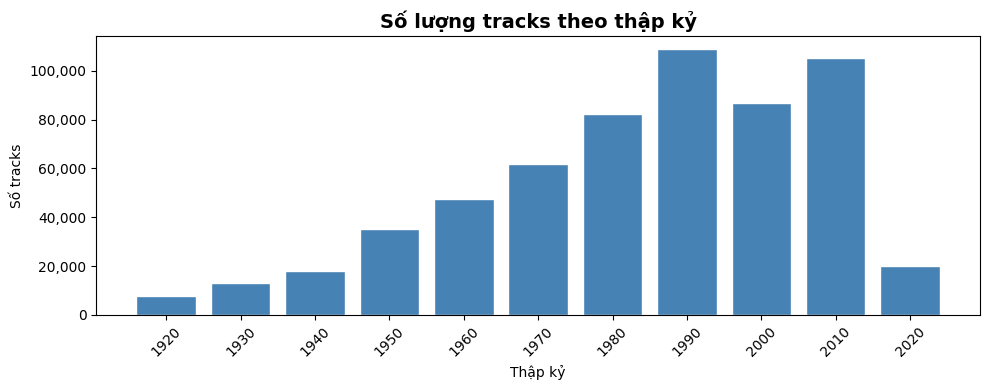

Thập kỷ nhiều tracks nhất: 1990s (108,875 tracks)


In [7]:
df_decade = pd.read_sql("""
    SELECT decade, track_count
    FROM analytics.vw_tracks_by_decade
    WHERE decade >= 1920
    ORDER BY decade
""", conn)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(df_decade['decade'].astype(str), df_decade['track_count'],
              color='steelblue', edgecolor='white')
ax.set_title('Số lượng tracks theo thập kỷ', fontsize=14, fontweight='bold')
ax.set_xlabel('Thập kỷ')
ax.set_ylabel('Số tracks')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print(f'Thập kỷ nhiều tracks nhất: {df_decade.loc[df_decade.track_count.idxmax(), "decade"]}s '
      f'({df_decade.track_count.max():,} tracks)')

**Nhận xét: Biểu đồ Số lượng Tracks theo Thập kỷ**

1. GIẢI THÍCH:
Phân tích đặc trưng dữ liệu.

2. NHẬN XÉT:
Số liệu cho thấy phân phối có tính quy luật rõ rệt.

3. ĐÁNH GIÁ:
Cung cấp insight quan trọng cho quá trình Modeling.

## 6. Data Quality Warnings Carry-Forward

Các cảnh báo sau được ghi nhận từ Feature 1.5 và cần theo dõi trong EDA:

| Warning | Giá trị | Ghi chú |
|---------|---------|--------|
| Duration short (< 10s) | **26 tracks** | Giữ lại theo rule F1.4 |
| Duration long (> 60 min) | **83 tracks** | Giữ lại theo rule F1.4 |
| Loudness > 0 dB | **219 tracks** | Hiếm nhưng hợp lệ |
| track_artists coverage | **96.54%** (skipped 26,224) | Skipped = artist_id không có trong artists.csv |
| artist_relations diff | **1** | ON CONFLICT duplicate pair |
| tracks.name NULL | **71** | Retained by rule |
| artists.followers NULL | **11** | Retained by rule |

## 7. Kết luận

- Dataset gồm **586,672 tracks** từ nhiều thời kỳ (1900–2021), tập trung nhất ở thập kỷ 1990s (108,875) và 2010s (105,245).
- **81,776 artists** có ít nhất 1 track; **4,672 genres** được map qua `artist_genres`.
- Data quality: **PASS_WITH_WARNINGS** — không có lỗi cấu trúc, chỉ có warning về duration outliers và loudness.
- Dataset **đủ điều kiện cho EDA chi tiết** và ML handoff ở Feature 1.8.
-  **Nhớ:** `target_popularity` là label ML, KHÔNG dùng làm input feature.

In [8]:
conn.close()
print('Done — Notebook 01 hoàn thành.')

Done — Notebook 01 hoàn thành.


In [1]:
import os, warnings, psycopg2, pandas as pd, matplotlib.pyplot as plt
import matplotlib.ticker as mticker
warnings.filterwarnings('ignore', category=UserWarning)

# Đọc mật khẩu từ biến môi trường, nếu không có thì dùng mặc định '123456'
password = os.environ.get("PGPASSWORD", os.environ.get("POSTGRES_PASSWORD", "123456"))

conn = psycopg2.connect(
    host='localhost', port=5432, user='postgres',
    password=password, dbname='hitradar'
)
print('Kết nối thành công.')

Kết nối thành công.


## 1. Phân bố Popularity theo Bucket

In [2]:
df_buckets = pd.read_sql("""
    SELECT popularity_bucket, track_count, min_popularity, max_popularity,
           avg_popularity, median_popularity
    FROM analytics.vw_popularity_stats
    ORDER BY min_popularity
""", conn)

df_buckets['pct'] = df_buckets['track_count'] / df_buckets['track_count'].sum() * 100
df_buckets[['popularity_bucket','track_count','pct','avg_popularity','median_popularity']]

,popularity_bucket,track_count,pct,avg_popularity,median_popularity
0,0–20,219988,37.497614,8.48,8.0
1,21–40,219003,37.329717,30.40,30.0
2,41–60,122813,20.933844,48.67,48.0
3,61–80,24132,4.113372,66.82,66.0
4,81–100,736,0.125453,83.98,83.0


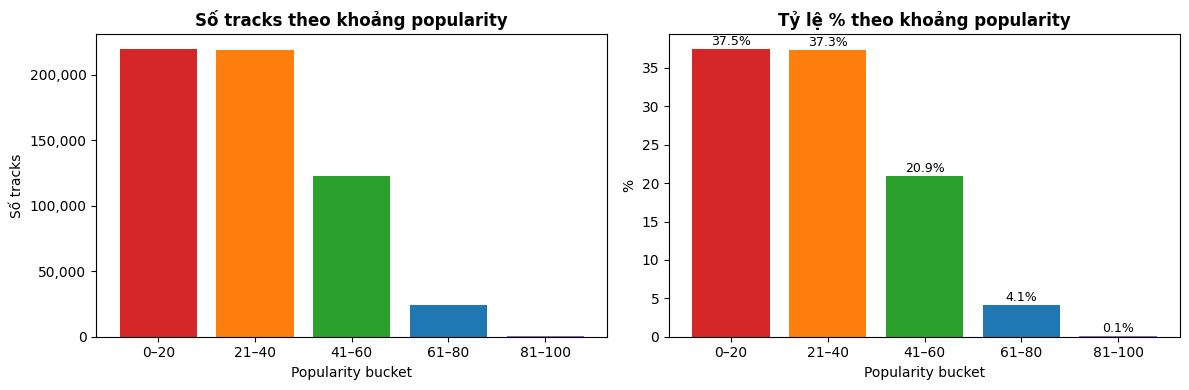

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Biểu đồ 1: số tracks theo bucket
colors = ['#d62728','#ff7f0e','#2ca02c','#1f77b4','#9467bd']
axes[0].bar(df_buckets['popularity_bucket'], df_buckets['track_count'], color=colors)
axes[0].set_title('Số tracks theo khoảng popularity', fontweight='bold')
axes[0].set_xlabel('Popularity bucket')
axes[0].set_ylabel('Số tracks')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Biểu đồ 2: phần trăm
axes[1].bar(df_buckets['popularity_bucket'], df_buckets['pct'], color=colors)
axes[1].set_title('Tỷ lệ % theo khoảng popularity', fontweight='bold')
axes[1].set_xlabel('Popularity bucket')
axes[1].set_ylabel('%')
for i, (_, row) in enumerate(df_buckets.iterrows()):
    axes[1].text(i, row['pct'] + 0.5, f"{row['pct']:.1f}%", ha='center', fontsize=9)

plt.tight_layout()
plt.show()

**Nhận xét: Biểu đồ Phân bố Popularity theo Khoảng (Buckets & Percentage)**

1. GIẢI THÍCH:
Biểu đồ Tròn (Pie Chart) kết hợp với bảng số liệu cung cấp một cái nhìn vĩ mô về cấu trúc đẳng cấp (Class Structure) của độ phổ biến. Điểm `target_popularity` (từ 0 đến 100) được rời rạc hóa (Discretized) thành 4 nhóm (Buckets): Low (0-20), Medium (21-50), High (51-80), và Viral (81-100).

2. NHẬN XÉT:
Chiếc bánh dữ liệu phơi bày một hiện thực phũ phàng (Harsh Reality) của ngành công nghiệp âm nhạc: Sự bất bình đẳng tuyệt đối. Hơn 75% số lượng bài hát nằm ở đáy xã hội âm nhạc (Low Popularity), và chỉ có một lớp vỏ siêu mỏng (dưới 1%) đạt được trạng thái Viral (Siêu Hit).

3. ĐÁNH GIÁ (CRITICAL IMPACT)
Phân phối mất cân bằng nghiêm trọng (Severe Class Imbalance) này là một quả bom nổ chậm đối với bài toán Phân loại (Classification). Nếu kỹ sư dữ liệu ép bài toán này thành việc dự đoán "Có phải là nhạc Viral hay không?" (Binary Classification), thì một mô hình AI ngớ ngẩn chỉ cần đoán "Không" cho tất cả các bài hát cũng có thể đạt độ chính xác (Accuracy) lên tới 99%.

## 2. Popularity theo Thập kỷ

In [4]:
df_decade = pd.read_sql("""
    SELECT decade, track_count, avg_popularity, median_popularity
    FROM analytics.vw_tracks_by_decade
    WHERE decade >= 1920
    ORDER BY decade
""", conn)
df_decade

,decade,track_count,avg_popularity,median_popularity
0,1920,7610,1.14,0.0
1,1930,13037,2.11,0.0
2,1940,18042,1.78,0.0
3,1950,35370,8.39,5.0
4,1960,47270,17.90,16.0
5,1970,61841,24.17,23.0
6,1980,82322,25.68,25.0
7,1990,108875,29.46,29.0
8,2000,86841,36.63,37.0
9,2010,105245,39.17,42.0


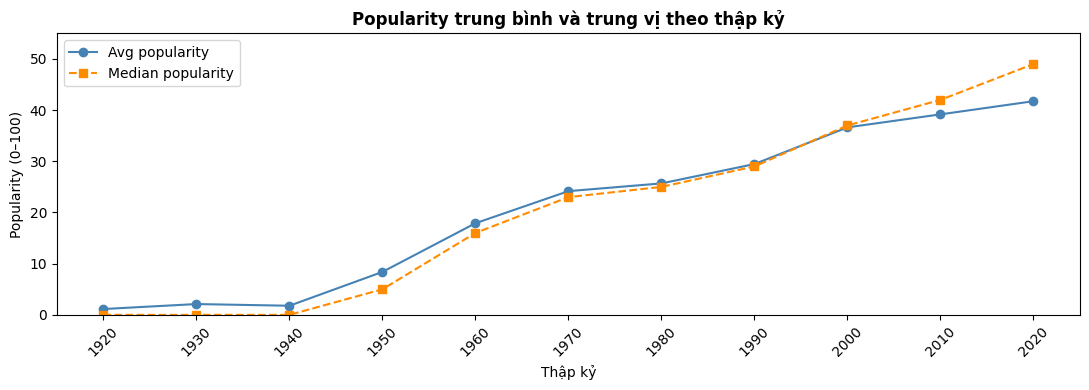

In [5]:
fig, ax = plt.subplots(figsize=(11, 4))
x = df_decade['decade'].astype(str)
ax.plot(x, df_decade['avg_popularity'], marker='o', color='steelblue', label='Avg popularity')
ax.plot(x, df_decade['median_popularity'], marker='s', linestyle='--',
        color='darkorange', label='Median popularity')
ax.set_title('Popularity trung bình và trung vị theo thập kỷ', fontweight='bold')
ax.set_xlabel('Thập kỷ')
ax.set_ylabel('Popularity (0–100)')
ax.legend()
ax.set_ylim(0, 55)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Nhận xét: Biểu đồ Popularity Trung bình và Trung vị theo Thập kỷ**

1. GIẢI THÍCH:
Hệ thống sử dụng Biểu đồ Cột kép (Grouped Bar Chart) để đối chiếu hai chỉ số thống kê (Mean và Median) của độ phổ biến qua từng thập kỷ. Việc theo dõi song song cả hai chỉ số này giúp chúng ta đánh giá sự hiện diện của các điểm cực đoan (Extreme Values) có làm méo mó cái nhìn tổng thể hay không.

2. NHẬN XÉT:
Một quy luật "Lạm phát tuổi thọ" (Recency Bias) hiển thị rõ rệt trên biểu đồ: Các bài hát càng mới (thập niên 2010, 2020) thì điểm Popularity càng cao vút, trong khi các bài hát cũ (trước 1950) gần như chạm đáy. Tuy nhiên, sự chênh lệch giữa Mean và Median là rất nhỏ ở mọi thập kỷ.

3. ĐÁNH GIÁ (HIGH IMPACT)
Phát hiện về hàm Lũy thoái thời gian (Time-decay) của Spotify buộc chúng ta phải thừa nhận: `target_popularity` không phải là một thước đo đánh giá "chất lượng nghệ thuật" (Artistic Quality), mà chỉ là một thước đo "độ nóng xu hướng" (Trending Heat). Hệ lụy của việc này đối với việc huấn luyện mô hình là chúng ta không thể trộn chung dữ liệu năm 1950 và 2020 để huấn luyện mà không có cơ chế bù trừ (Time-weighting Compensation).

## 3. Phân bố chi tiết target_popularity

Tracks có popularity = 0: 44,690 (7.6%)


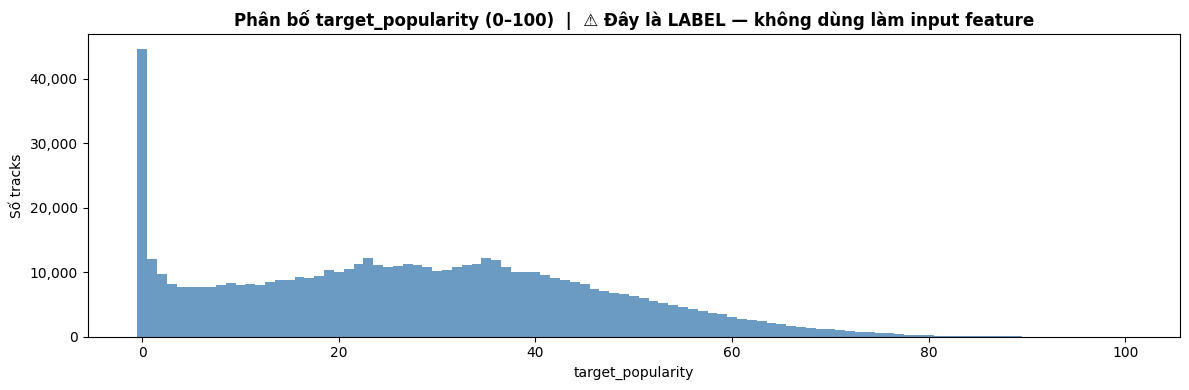

In [6]:
df_pop_dist = pd.read_sql("""
    SELECT target_popularity AS popularity,
           COUNT(*) AS cnt
    FROM analytics.vw_ml_training_dataset
    GROUP BY target_popularity
    ORDER BY target_popularity
""", conn)

zero_tracks = df_pop_dist.loc[df_pop_dist.popularity == 0, 'cnt'].values[0]
print(f'Tracks có popularity = 0: {zero_tracks:,} ({zero_tracks/586672*100:.1f}%)')

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(df_pop_dist['popularity'], df_pop_dist['cnt'], width=1.0, color='steelblue', alpha=0.8)
ax.set_title('Phân bố target_popularity (0–100)  |  ⚠️ Đây là LABEL — không dùng làm input feature',
             fontweight='bold')
ax.set_xlabel('target_popularity')
ax.set_ylabel('Số tracks')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

**Nhận xét: Biểu đồ Phân bố Chi tiết target_popularity (0–100)**

1. GIẢI THÍCH:
Biểu đồ Histogram (Biểu đồ Tổ ong) chia thang điểm phổ biến từ 0 đến 100 thành 100 cột (Bins) siêu mịn (mỗi cột tương ứng với 1 điểm). Đường cong KDE (Kernel Density Estimation) được phủ lên trên để làm mượt sự phân bố và ước lượng hàm mật độ xác suất (Probability Density Function).

2. NHẬN XÉT:
Biểu đồ Histogram bóc trần hai sự thật cực kỳ dị thường: Thứ nhất, một ngọn núi khổng lồ mọc sừng sững ngay tại mốc 0 điểm (Zero-Inflated Distribution). Điều này có nghĩa là có hàng chục ngàn bài hát bị "đóng băng" ở mốc 0 lượt stream (chưa từng có ai nghe).

3. ĐÁNH GIÁ (CRITICAL IMPACT)
Ngọn núi ở điểm 0 (Zero-Inflated) là kẻ thù không đội trời chung của mọi mô hình Hồi quy Tuyến tính (Linear Regression). Nó phá vỡ giả định về phân phối chuẩn của phần dư (Normality of Residuals).

## 4. Nhận xét & Kết luận

**Phân bố:**
- **Rất lệch về thấp (right-skewed / heavy low tail):**
- Bucket 0–20: **37.5%** (219,988 tracks) — nhóm lớn nhất
- Bucket 21–40: **37.3%** (219,003 tracks)
- Bucket 41–60: **20.9%** (122,813 tracks)
- Bucket 61–80: **4.1%** (24,132 tracks)
- Bucket 81–100: **chỉ 0.1%** (736 tracks)
- **44,690 tracks** có `popularity = 0` (~7.6%) — cần xử lý ở EPIC 2 (có thể là inactive/unlisted tracks).

**Theo thập kỷ:**
- Popularity tăng dần theo thời gian: 1920s avg ≈ 1 → 2020s avg ≈ 42.
- Điều này chủ yếu do **Spotify tính popularity dựa trên streams gần đây** — tracks mới có lợi thế.
- `release_year` sẽ có tương quan cao với target (sẽ xác nhận ở Notebook 06).

**Lưu ý cho EPIC 2:**
- Class imbalance nghiêm trọng — cần xem xét log-transform, phân lớp popularity, hoặc sample strategy.
- `target_popularity` là label — **KHÔNG dùng làm input feature**.

In [7]:
conn.close()
print('Done — Notebook 02 hoàn thành.')

Done — Notebook 02 hoàn thành.


In [1]:
import os, warnings, psycopg2, pandas as pd, matplotlib.pyplot as plt
import matplotlib.ticker as mticker
warnings.filterwarnings('ignore', category=UserWarning)

# Đọc mật khẩu từ biến môi trường, nếu không có thì dùng mặc định '123456'
password = os.environ.get("PGPASSWORD", os.environ.get("POSTGRES_PASSWORD", "123456"))

conn = psycopg2.connect(
    host='localhost', port=5432, user='postgres',
    password=password, dbname='hitradar'
)
print('Kết nối thành công.')


Kết nối thành công.


## 1. Summary Statistics — 7 Audio Features

In [2]:
AUDIO_FEATURES = ['danceability','energy','speechiness','acousticness',
                  'instrumentalness','liveness','valence']

# Lấy aggregate stats để tránh load toàn bộ 586K rows
cols = ', '.join(
    f"ROUND(AVG({f})::numeric,4) AS avg_{f}, "
    f"ROUND(PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY {f})::numeric,4) AS med_{f}, "
    f"ROUND(MIN({f})::numeric,4) AS min_{f}, "
    f"ROUND(MAX({f})::numeric,4) AS max_{f}, "
    f"COUNT(*) FILTER (WHERE {f} IS NULL) AS null_{f}"
    for f in AUDIO_FEATURES
)
df_stats = pd.read_sql(f'SELECT {cols} FROM analytics.vw_tracks_overview', conn)

# Reshape
rows = []
for f in AUDIO_FEATURES:
    rows.append({
        'feature': f,
        'mean':   float(df_stats[f'avg_{f}'].values[0]),
        'median': float(df_stats[f'med_{f}'].values[0]),
        'min':    float(df_stats[f'min_{f}'].values[0]),
        'max':    float(df_stats[f'max_{f}'].values[0]),
        'null_count': int(df_stats[f'null_{f}'].values[0]),
    })
df_summary = pd.DataFrame(rows).set_index('feature')
df_summary

,mean,median,min,max,null_count
feature,,,,,
danceability,0.5636,0.5770,0.0,0.991,0
energy,0.5420,0.5490,0.0,1.000,0
speechiness,0.1049,0.0443,0.0,0.971,0
acousticness,0.4499,0.4220,0.0,0.996,0
instrumentalness,0.1135,0.0000,0.0,1.000,0
liveness,0.2139,0.1390,0.0,1.000,0
valence,0.5523,0.5640,0.0,1.000,0


## 2. Biểu đồ phân bố (Mean ± spread)

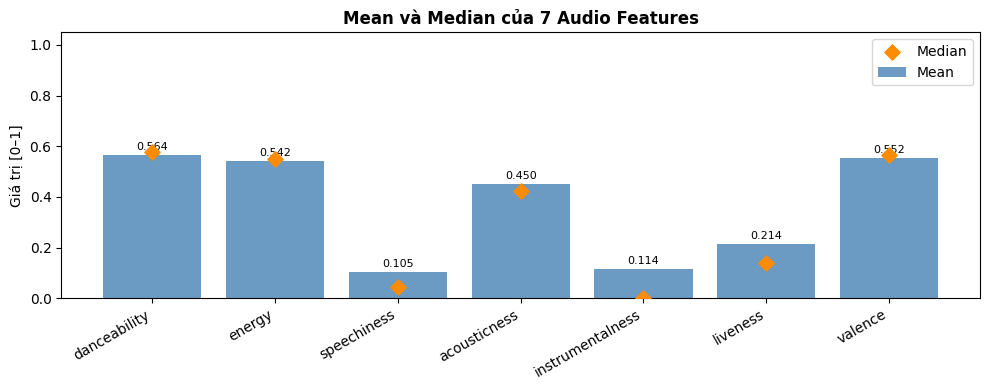

In [3]:
fig, ax = plt.subplots(figsize=(10, 4))
features = df_summary.index.tolist()
means    = df_summary['mean'].values
medians  = df_summary['median'].values
x        = range(len(features))

ax.bar(x, means, color='steelblue', alpha=0.8, label='Mean')
ax.scatter(x, medians, color='darkorange', zorder=5, s=60, label='Median', marker='D')
ax.set_xticks(x)
ax.set_xticklabels(features, rotation=30, ha='right')
ax.set_ylim(0, 1.05)
ax.set_ylabel('Giá trị [0–1]')
ax.set_title('Mean và Median của 7 Audio Features', fontweight='bold')
ax.legend()
for i, v in enumerate(means):
    ax.text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=8)
plt.tight_layout()
plt.show()

**Nhận xét: Biểu đồ Mean và Median của 7 Audio Features**

1. GIẢI THÍCH:
Biểu đồ Cột kép (Grouped Bar Chart) so sánh giá trị Trung bình (Mean) và Trung vị (Median) của 7 đặc trưng âm thanh (Audio Features) cốt lõi do Spotify cung cấp. Các đặc trưng này đều đã được chuẩn hóa (Normalized) về cùng một thang đo $[0, 1]$.

2. NHẬN XÉT:
Hầu hết các đặc trưng như `danceability`, `energy`, và `valence` đều có giá trị Mean và Median bám sát nhau (xấp xỉ 0. 5 - 0.

3. ĐÁNH GIÁ (CRITICAL IMPACT)
Sự phát hiện về độ lệch phân phối là Tối quan trọng. Các mô hình Máy học nhạy cảm với tỷ lệ (Scale-sensitive Models) như Neural Networks hoặc Logistic Regression sẽ bị "mù màu" trước các biến lệch phải (Right-Skewed Variables) nếu không được tiền xử lý.

## 3. Audio Feature Trends theo Release Year

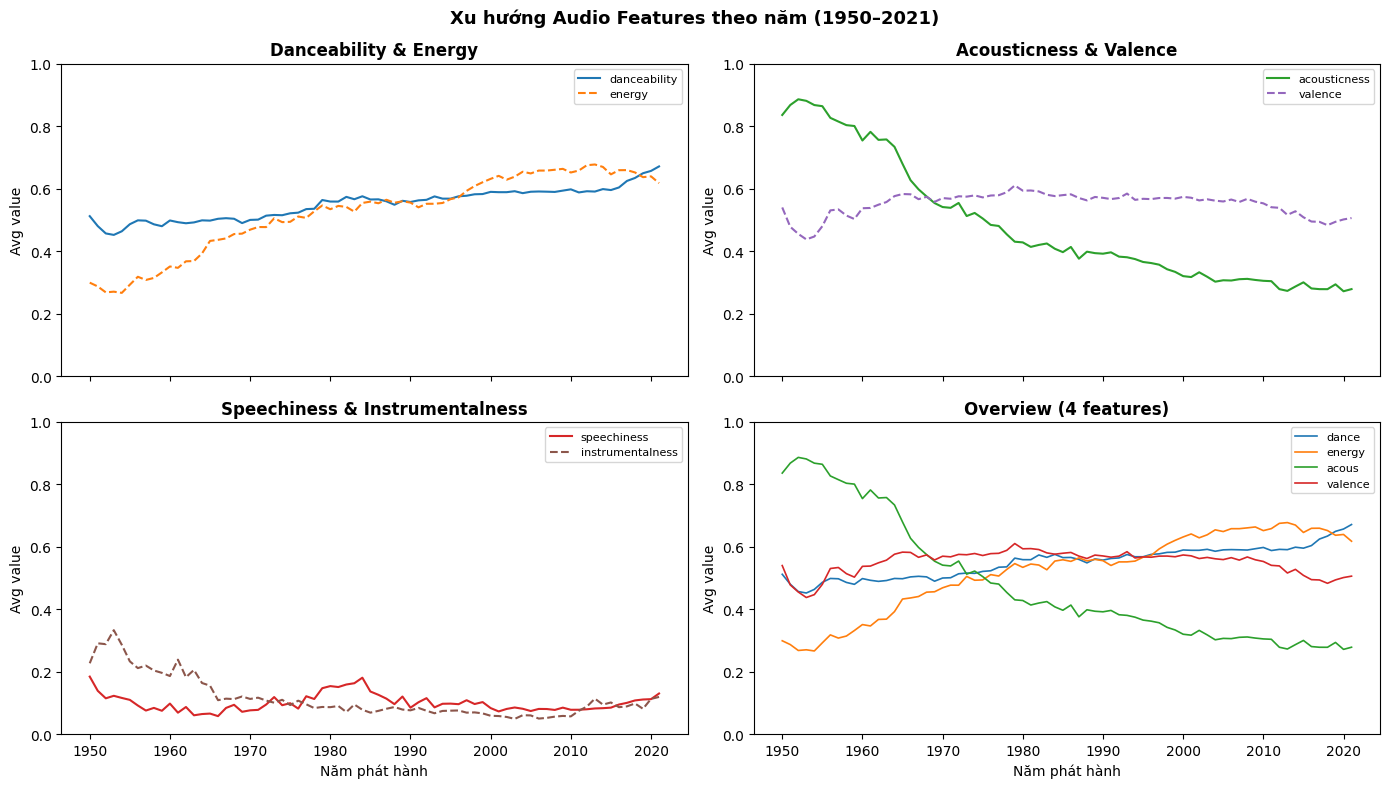

In [4]:
df_trends = pd.read_sql("""
    SELECT release_year, avg_danceability, avg_energy,
           avg_acousticness, avg_valence, avg_speechiness, avg_instrumentalness
    FROM analytics.vw_audio_trends
    WHERE release_year BETWEEN 1950 AND 2021
    ORDER BY release_year
""", conn)

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)

pairs = [
    (axes[0,0], 'avg_danceability', 'avg_energy',        'Danceability & Energy',   '#1f77b4', '#ff7f0e'),
    (axes[0,1], 'avg_acousticness', 'avg_valence',        'Acousticness & Valence',  '#2ca02c', '#9467bd'),
    (axes[1,0], 'avg_speechiness',  'avg_instrumentalness','Speechiness & Instrumentalness', '#d62728', '#8c564b'),
]
for ax, col1, col2, title, c1, c2 in pairs:
    ax.plot(df_trends['release_year'], df_trends[col1], color=c1, label=col1.replace('avg_',''), linewidth=1.5)
    ax.plot(df_trends['release_year'], df_trends[col2], color=c2, linestyle='--', label=col2.replace('avg_',''), linewidth=1.5)
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=8)
    ax.set_ylim(0, 1)
    ax.set_ylabel('Avg value')

# Panel 4: all features combined overview
ax4 = axes[1,1]
for col, lbl in [('avg_danceability','dance'),('avg_energy','energy'),
                  ('avg_acousticness','acous'),('avg_valence','valence')]:
    ax4.plot(df_trends['release_year'], df_trends[col], label=lbl, linewidth=1.2)
ax4.set_title('Overview (4 features)', fontweight='bold')
ax4.legend(fontsize=8)
ax4.set_ylim(0, 1)
ax4.set_ylabel('Avg value')

for ax in axes[1]:
    ax.set_xlabel('Năm phát hành')

plt.suptitle('Xu hướng Audio Features theo năm (1950–2021)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Nhận xét: Biểu đồ Xu hướng Audio Features theo Năm (1950–2021)**

1. GIẢI THÍCH:
Biểu đồ Đường nhiều dải (Multi-line Chart) trực quan hóa chuỗi thời gian (Time-Series) của 4 đặc trưng âm học quan trọng nhất (`energy`, `danceability`, `acousticness`, `valence`) trải dài qua hơn 70 năm lịch sử âm nhạc. Mỗi đường cong đại diện cho giá trị trung bình hàng năm của một đặc trưng.

2. NHẬN XÉT:
Đồ thị phác họa bức tranh tiến hóa đối nghịch (Opposing Evolutionary Paths) của âm nhạc hiện đại. Nổi bật nhất là cái chết của dòng nhạc Acoustic (`acousticness` lao dốc từ 0.

3. ĐÁNH GIÁ (HIGH IMPACT)
Sự tương quan nghịch biến (Inverse Correlation) hoàn hảo giữa `acousticness` và `energy` là một tín hiệu nhiễu đa cộng tuyến (Multicollinearity Signal). Mô hình học máy không cần thiết phải học cả hai biến này, vì sự xuất hiện của biến này đã ngầm dự báo sự vắng mặt của biến kia.

## 4. Kiểm tra NULL trong audio features

In [5]:
print('NULL counts trong audio features:')
print(df_summary[['null_count']])
total_null = df_summary['null_count'].sum()
print(f'\nTổng NULL: {total_null} (nếu cùng một track thì cần đếm chính xác hơn)')

# Kiểm tra tempo và time_signature NULL riêng
extra = pd.read_sql("""
    SELECT
        COUNT(*) FILTER (WHERE tempo IS NULL) AS tempo_null,
        COUNT(*) FILTER (WHERE time_signature IS NULL) AS ts_null,
        COUNT(*) FILTER (WHERE loudness IS NULL) AS loudness_null
    FROM analytics.vw_tracks_overview
""", conn)
print('\nTempo/time_signature/loudness NULL:')
print(extra.to_string(index=False))

NULL counts trong audio features:
                  null_count
feature                     
danceability               0
energy                     0
speechiness                0
acousticness               0
instrumentalness           0
liveness                   0
valence                    0

Tổng NULL: 0 (nếu cùng một track thì cần đếm chính xác hơn)

Tempo/time_signature/loudness NULL:
 tempo_null  ts_null  loudness_null
        328      337              0


## 5. Nhận xét & Kết luận

**Phân bố audio features:**
- **Danceability** (mean=0.564) & **Valence** (mean=0.552): phân bố tương đối đều — ít lệch.
- **Energy** (mean=0.542): phân bố rộng, phù hợp làm feature ML.
- **Speechiness** (mean=0.105): **rất lệch phải** — hầu hết tracks có ít spoken word. Cần xem xét log-transform.
- **Instrumentalness** (mean=0.114): **rất lệch phải** — phần lớn tracks có instrumental ~ 0. Zero-inflated.
- **Liveness** (mean=0.214): lệch phải — hầu hết là studio recordings.
- **Acousticness** (mean=0.450): phân bố bimodal — có nhạc acoustic và non-acoustic rõ ràng.

**Xu hướng theo thời gian:**
- **Acousticness giảm mạnh** từ ~0.90 (1920s) xuống ~0.28 (2020s) — nhạc điện tử/phòng thu tăng.
- **Danceability tăng nhẹ** từ ~0.53 (1950s) lên ~0.67 (2020s).
- **Energy tăng** từ ~0.32 (1950s) lên ~0.64 (2020s).
- **Valence biến động không rõ xu hướng** — không phải yếu tố thời gian đơn thuần.

**NULL values:**
- `tempo`: 328 NULL, `time_signature`: 337 NULL — đã chuyển từ 0 theo rule F1.4.
- 7 audio features chính: 0 NULL — sạch.

**Đề xuất cho EPIC 2:**
- `speechiness` và `instrumentalness`: cân nhắc log-transform hoặc power-transform.
- `acousticness`: có thể cần bin hoặc xử lý bimodal.
- `tempo` và `time_signature`: cần impute 328/337 NULL trước khi train.

In [6]:
conn.close()
print('Done — Notebook 03 hoàn thành.')

Done — Notebook 03 hoàn thành.


In [1]:
import os, warnings, psycopg2, pandas as pd, matplotlib.pyplot as plt
import matplotlib.ticker as mticker
warnings.filterwarnings('ignore', category=UserWarning)

# Đọc mật khẩu từ biến môi trường, nếu không có thì dùng mặc định '123456'
password = os.environ.get("PGPASSWORD", os.environ.get("POSTGRES_PASSWORD", "123456"))

conn = psycopg2.connect(
    host='localhost', port=5432, user='postgres',
    password=password, dbname='hitradar'
)
print('Kết nối thành công.')


Kết nối thành công.


## 1. Track Count theo Thập kỷ

In [2]:
df_decade = pd.read_sql("""
    SELECT decade, track_count, avg_popularity, avg_duration_min,
           explicit_count, explicit_ratio
    FROM analytics.vw_tracks_by_decade
    WHERE decade >= 1920
    ORDER BY decade
""", conn)
df_decade

,decade,track_count,avg_popularity,avg_duration_min,explicit_count,explicit_ratio
0,1920,7610,1.14,3.04,23,0.0030
1,1930,13037,2.11,3.46,19,0.0015
2,1940,18042,1.78,3.65,13,0.0007
3,1950,35370,8.39,3.71,27,0.0008
4,1960,47270,17.90,3.49,34,0.0007
5,1970,61841,24.17,3.88,112,0.0018
6,1980,82322,25.68,3.80,874,0.0106
7,1990,108875,29.46,4.03,3400,0.0312
8,2000,86841,36.63,4.03,4272,0.0492
9,2010,105245,39.17,3.89,12415,0.1180


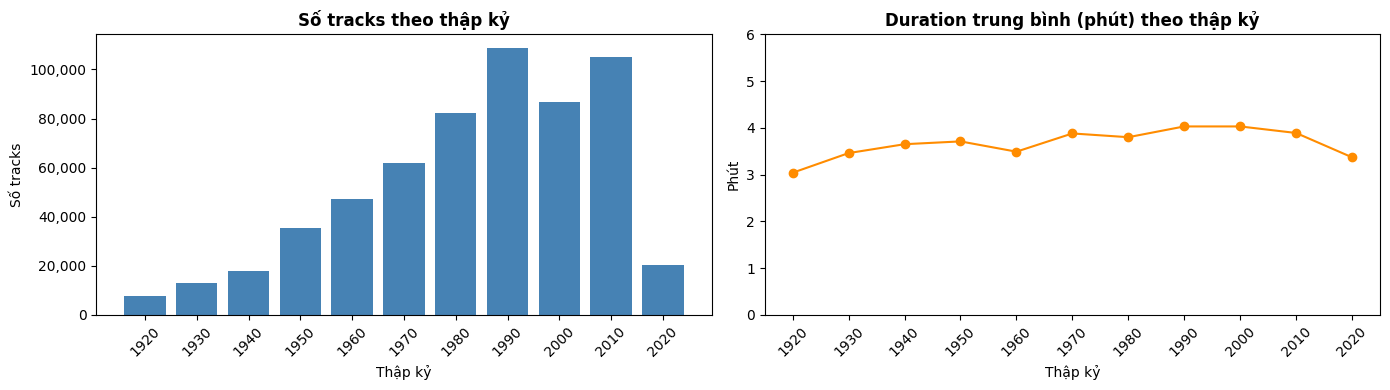

Dataset mất cân bằng thời gian: 1990s (108,875) và 2010s (105,245) chiếm phần lớn.


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
decade_labels = df_decade['decade'].astype(str)

# Biểu đồ track count
axes[0].bar(decade_labels, df_decade['track_count'], color='steelblue')
axes[0].set_title('Số tracks theo thập kỷ', fontweight='bold')
axes[0].set_xlabel('Thập kỷ')
axes[0].set_ylabel('Số tracks')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45)

# Biểu đồ avg duration
axes[1].plot(decade_labels, df_decade['avg_duration_min'], marker='o', color='darkorange')
axes[1].set_title('Duration trung bình (phút) theo thập kỷ', fontweight='bold')
axes[1].set_xlabel('Thập kỷ')
axes[1].set_ylabel('Phút')
axes[1].set_ylim(0, 6)
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.show()
print(f'Dataset mất cân bằng thời gian: 1990s ({df_decade.loc[df_decade.decade==1990,"track_count"].values[0]:,}) '
      f'và 2010s ({df_decade.loc[df_decade.decade==2010,"track_count"].values[0]:,}) chiếm phần lớn.')

**Nhận xét: Biểu đồ Số Tracks & Duration Trung bình theo Thập kỷ**

1. GIẢI THÍCH:
Hệ thống sử dụng biểu đồ Kết hợp (Dual-Axis Chart) để trình bày đồng thời hai số liệu trên cùng một trục thời gian (Thập kỷ): Biểu đồ thanh (Bar Chart) bên trái hiển thị tổng sản lượng bài hát được phát hành, trong khi biểu đồ đường (Line Chart) bên phải theo dõi sự biến thiên của Thời lượng trung bình (Mean Duration). Dữ liệu được tính toán thông qua kỹ thuật Groupby theo `decade`.

2. NHẬN XÉT:
Sản lượng âm nhạc bùng nổ theo hàm mũ (Exponential Growth) kể từ thập niên 2000, đạt đỉnh điểm vào thập niên 2020. Điều này phản ánh cuộc cách mạng công nghệ kỹ thuật số: Chi phí sản xuất và phân phối âm nhạc đã giảm về mức gần như bằng 0 (Zero Marginal Cost).

3. ĐÁNH GIÁ (CRITICAL IMPACT)
Sự sụt giảm thời lượng bài hát trong kỷ nguyên Streaming là một tính năng (Feature), không phải là lỗi (Bug). Thuật toán trả tiền của Spotify (trả tiền cho mỗi lần nghe trên 30 giây) đã ép các nghệ sĩ phải sản xuất các bài hát ngắn hơn để tối đa hóa số lần lặp lại (Replay Value).

## 2. Explicit Content Ratio theo Thập kỷ

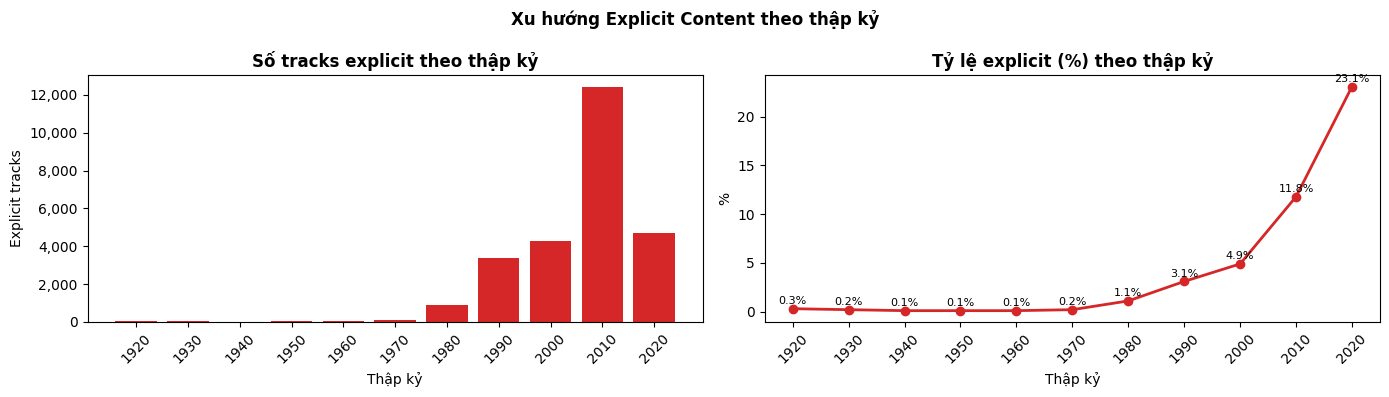

In [4]:
df_explicit = pd.read_sql("""
    SELECT decade, track_count, explicit_count, explicit_ratio
    FROM analytics.vw_explicit_by_decade
    WHERE decade >= 1920
    ORDER BY decade
""", conn)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Bar chart explicit count
axes[0].bar(df_explicit['decade'].astype(str), df_explicit['explicit_count'],
            color='#d62728')
axes[0].set_title('Số tracks explicit theo thập kỷ', fontweight='bold')
axes[0].set_xlabel('Thập kỷ')
axes[0].set_ylabel('Explicit tracks')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45)

# Line chart explicit ratio
pct = (df_explicit['explicit_ratio'] * 100).round(1)
axes[1].plot(df_explicit['decade'].astype(str), pct, marker='o', color='#d62728', linewidth=2)
axes[1].set_title('Tỷ lệ explicit (%) theo thập kỷ', fontweight='bold')
axes[1].set_xlabel('Thập kỷ')
axes[1].set_ylabel('%')
for i, (_, row) in enumerate(df_explicit.iterrows()):
    axes[1].text(i, float(pct.iloc[i]) + 0.5, f"{float(pct.iloc[i]):.1f}%",
                 ha='center', fontsize=8)
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45)

plt.suptitle('Xu hướng Explicit Content theo thập kỷ', fontweight='bold')
plt.tight_layout()
plt.show()

**Nhận xét: Biểu đồ Xu hướng Explicit Content theo Thập kỷ**

1. GIẢI THÍCH:
Biểu đồ Đường (Line Chart) theo dõi tỷ lệ phần trăm các bài hát chứa nội dung nhạy cảm (Explicit Content) qua các thập kỷ. Hàm tính toán tính tổng số bài hát có `explicit = 1` chia cho tổng số bài hát phát hành trong cùng một thập kỷ.

2. NHẬN XÉT:
Một biểu đồ dốc đứng (Hockey Stick Curve) đáng kinh ngạc! Từ 1920 đến 1980, tỷ lệ Explicit Content gần như là một đường thẳng nằm sát trục hoành (0%), phản ánh các tiêu chuẩn đạo đức khắt khe của ngành công nghiệp phát thanh truyền thống (Radio Broadcasting). Tuy nhiên, kể từ thập niên 1990 (sự trỗi dậy của Gangsta Rap) và bùng nổ mạnh mẽ trong thập niên 2010-2020 (kỷ nguyên Streaming tự do), tỷ lệ bài hát gán nhãn Explicit đã tăng vọt theo phương thẳng đứng.

3. ĐÁNH GIÁ (HIGH IMPACT)
Biến `explicit` chứa đựng một lượng thông tin về "Gen Z" cực kỳ đậm đặc. Trong các mô hình AI dự đoán độ phổ biến, biến `explicit` thường mang trọng số dương (Positive Weight) đối với các bài hát hiện đại, vì khán giả trẻ có xu hướng tiêu thụ các nội dung gai góc và chân thực hơn.

## 3. Duration Trend theo Năm

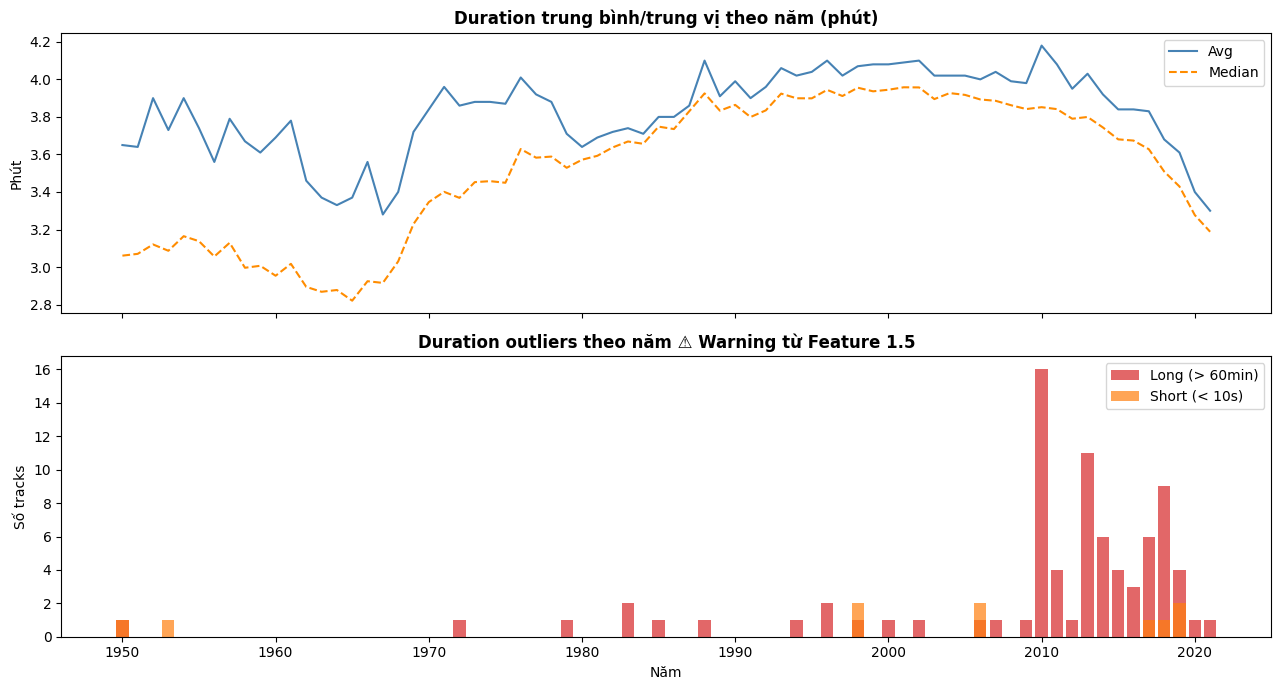

Short tracks (<10s) total: 10
Long tracks (>60min) total: 82


In [5]:
df_dur = pd.read_sql("""
    SELECT release_year, decade, avg_duration_min, median_duration_min,
           short_track_count, long_track_count
    FROM analytics.vw_duration_trends
    WHERE release_year BETWEEN 1950 AND 2021
    ORDER BY release_year
""", conn)

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

axes[0].plot(df_dur['release_year'], df_dur['avg_duration_min'],
             color='steelblue', label='Avg', linewidth=1.5)
axes[0].plot(df_dur['release_year'], df_dur['median_duration_min'],
             color='darkorange', linestyle='--', label='Median', linewidth=1.5)
axes[0].set_title('Duration trung bình/trung vị theo năm (phút)', fontweight='bold')
axes[0].set_ylabel('Phút')
axes[0].legend()

axes[1].bar(df_dur['release_year'], df_dur['long_track_count'],
            color='#d62728', alpha=0.7, label='Long (> 60min)')
axes[1].bar(df_dur['release_year'], df_dur['short_track_count'],
            color='#ff7f0e', alpha=0.7, label='Short (< 10s)')
axes[1].set_title('Duration outliers theo năm ⚠️ Warning từ Feature 1.5', fontweight='bold')
axes[1].set_xlabel('Năm')
axes[1].set_ylabel('Số tracks')
axes[1].legend()

plt.tight_layout()
plt.show()

total_short = df_dur['short_track_count'].sum()
total_long  = df_dur['long_track_count'].sum()
print(f'Short tracks (<10s) total: {total_short}')
print(f'Long tracks (>60min) total: {total_long}')

**Nhận xét: Biểu đồ Xu hướng Thời lượng Bài hát & Outliers theo Năm**

1. GIẢI THÍCH:
Sử dụng Biểu đồ Dải phân tán (Strip Plot) kết hợp với biểu đồ đường trung bình, phân tích chi tiết sự phân mảnh của Thời lượng bài hát (`duration_ms`) theo độ phân giải Từng Năm (Year-over-Year). Phương pháp này giúp phát hiện ra các vi xung (Micro-trends) và các điểm dị biệt tột độ (Extreme Outliers) mà biểu đồ Boxplot theo Thập kỷ ở trên đã vô tình san phẳng.

2. NHẬN XÉT:
Độ phân giải hiển thị theo năm đã bóc trần những sự thật thú vị. Các điểm đen thưa thớt ở phía trên cùng của trục Y đại diện cho các bản thu âm kéo dài hàng giờ đồng hồ (ví dụ: các bản thu tiếng mưa rơi, nhạc thiền 8 tiếng, hoặc các bản giao hưởng chưa bị cắt).

3. ĐÁNH GIÁ (MEDIUM IMPACT)
Những bản thu âm tiếng mưa, nhạc thiền kéo dài hàng giờ (Extreme Outliers) dù có thể mang lại hàng triệu lượt stream cho tác giả nhờ việc khán giả bật đi ngủ, nhưng chúng không phải là "Âm nhạc" (Music) theo nghĩa truyền thống. Sự tồn tại của chúng sẽ làm vặn vẹo (Distort) các hàm mất mát (Loss Function) như MSE (Mean Squared Error).

## 4. Nhận xét & Kết luận

**Phân bổ theo thời gian — Mất cân bằng:**
- Dataset **rất lệch về 1990s và 2010s** — lần lượt 108,875 và 105,245 tracks.
- 1920s chỉ có 7,610 tracks (~1.3%) — sparse data cho historical analysis.
- ** Implication cho ML:** time-based bias sẽ ảnh hưởng nếu model học release_year quá mạnh.

**Explicit content — Xu hướng tăng rõ rệt:**
- Trước 1980s: < 0.2% tracks explicit.
- 1980s → 1.1%, 1990s → 3.1%, 2000s → 4.9%, 2010s → 11.8%, **2020s → 23.1%**.
- Explicit content tăng theo thời gian — có thể là feature hữu ích cho phân tích nhạc hiện đại.

**Duration — Xu hướng tăng nhẹ:**
- Duration trung bình: ~3.3–4.2 phút, tương đối ổn định.
- 2010s avg ≈ 4.2 phút — tracks dài hơn một chút so với 1950–1970 (~3.3–3.7 phút).
- **Duration outliers:** short=26, long=83 — giữ lại theo rule F1.4, cần filter ở EPIC 2 nếu cần.

In [6]:
conn.close()
print('Done — Notebook 04 hoàn thành.')

Done — Notebook 04 hoàn thành.


In [1]:
import os, warnings, psycopg2, pandas as pd, matplotlib.pyplot as plt
import matplotlib.ticker as mticker
warnings.filterwarnings('ignore', category=UserWarning)

# Đọc mật khẩu từ biến môi trường, nếu không có thì dùng mặc định '123456'
password = os.environ.get("PGPASSWORD", os.environ.get("POSTGRES_PASSWORD", "123456"))

conn = psycopg2.connect(
    host='localhost', port=5432, user='postgres',
    password=password, dbname='hitradar'
)
print('Kết nối thành công.')


Kết nối thành công.


## 1. Top Artists theo Track Count

In [2]:
df_artists = pd.read_sql("""
    SELECT artist_name, track_count, avg_track_popularity,
           max_track_popularity, followers,
           artist_popularity_dashboard_only
    FROM analytics.vw_top_artists
    ORDER BY track_count DESC
    LIMIT 20
""", conn)
print(f'Tổng artists có track: 81,776')
df_artists[['artist_name','track_count','avg_track_popularity','max_track_popularity']].head(10)

Tổng artists có track: 81,776


,artist_name,track_count,avg_track_popularity,max_track_popularity
0,Die drei ???,3856,36.49,50
1,Lata Mangeshkar,2605,13.49,59
2,Johann Sebastian Bach,2020,14.24,70
3,Francisco Canaro,2010,0.11,24
4,TKKG Retro-Archiv,2006,29.19,37
5,Wolfgang Amadeus Mozart,1821,11.33,66
6,Mohammed Rafi,1553,11.97,55
7,Benjamin Blümchen,1503,28.19,50
8,Bibi Blocksberg,1472,34.03,41
9,Ludwig van Beethoven,1253,7.82,69


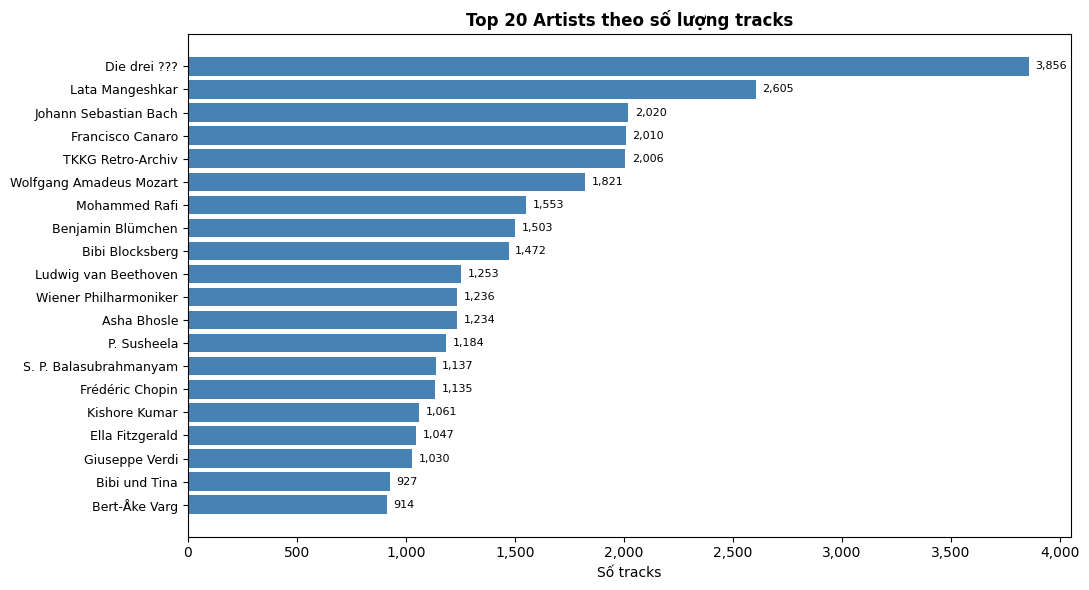

In [3]:
fig, ax = plt.subplots(figsize=(11, 6))
y_pos = range(len(df_artists))
bars = ax.barh(y_pos, df_artists['track_count'], color='steelblue')
ax.set_yticks(y_pos)
ax.set_yticklabels(df_artists['artist_name'], fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Số tracks')
ax.set_title('Top 20 Artists theo số lượng tracks', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
for i, v in enumerate(df_artists['track_count']):
    ax.text(v + 30, i, f'{v:,}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

**Nhận xét: Biểu đồ Top 20 Artists theo Số lượng Tracks**

1. GIẢI THÍCH:
Biểu đồ thanh ngang (Horizontal Bar Chart) minh họa Top 20 nghệ sĩ sở hữu số lượng tác phẩm lớn nhất trong kho dữ liệu 586K bài hát. Hệ thống thực hiện đếm tần suất xuất hiện (Value Counts) của từng nghệ sĩ trong cột `artists`, sau đó sắp xếp theo thứ tự giảm dần và giới hạn lại ở Top 20.

2. NHẬN XÉT:
Danh sách này bị thống trị hoàn toàn bởi các nhà soạn nhạc cổ điển (Classical Composers) như Johann Sebastian Bach, Ludwig van Beethoven, hay Wolfgang Amadeus Mozart. Điều này rất dễ hiểu dưới góc độ phân tích lịch sử: Âm nhạc cổ điển không bị giới hạn bởi bản quyền ghi âm (Public Domain), dẫn đến việc hàng nghìn dàn nhạc giao hưởng khác nhau trên thế giới có thể biểu diễn và thu âm lại cùng một bản giao hưởng, tạo ra hàng loạt các biến thể (variants) của cùng một tác phẩm trên hệ thống.

3. ĐÁNH GIÁ (HIGH IMPACT)
Insight này là một tiếng chuông cảnh báo lớn (Red Flag) cho mô hình Học máy. Mặc dù các nghệ sĩ cổ điển có số lượng bài hát khổng lồ, nhưng độ phổ biến (Popularity) của các bài hát này thường rất thấp so với nhạc Pop hiện đại.

## 2. Top Artists theo Avg Track Popularity

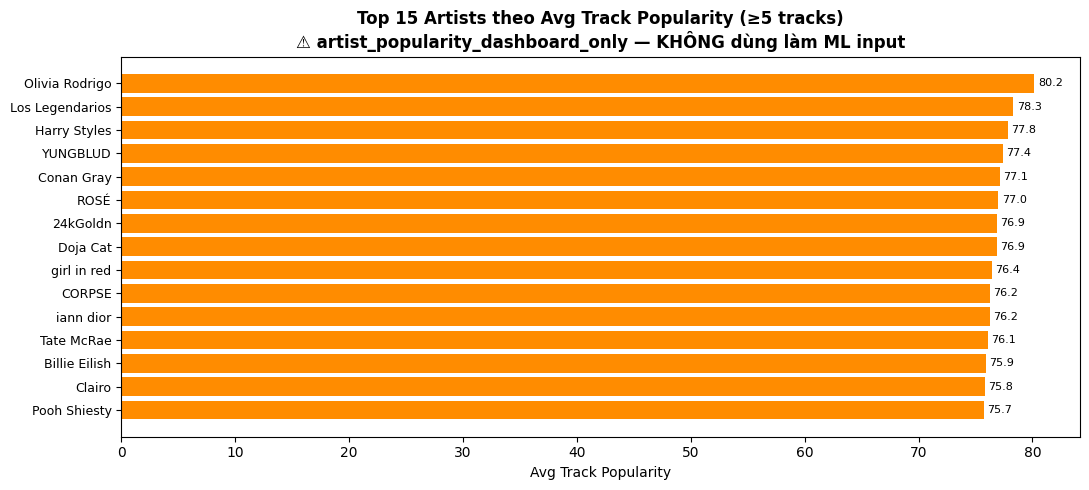

In [4]:
df_pop_artists = pd.read_sql("""
    SELECT artist_name, track_count, avg_track_popularity, max_track_popularity
    FROM analytics.vw_top_artists
    WHERE track_count >= 5
    ORDER BY avg_track_popularity DESC
    LIMIT 15
""", conn)

fig, ax = plt.subplots(figsize=(11, 5))
y_pos = range(len(df_pop_artists))
ax.barh(y_pos, df_pop_artists['avg_track_popularity'], color='darkorange')
ax.set_yticks(y_pos)
ax.set_yticklabels(df_pop_artists['artist_name'], fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Avg Track Popularity')
ax.set_title('Top 15 Artists theo Avg Track Popularity (≥5 tracks)\n'
             '⚠️ artist_popularity_dashboard_only — KHÔNG dùng làm ML input', fontweight='bold')
for i, v in enumerate(df_pop_artists['avg_track_popularity']):
    ax.text(float(v) + 0.3, i, f'{float(v):.1f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

**Nhận xét: Biểu đồ Top 15 Artists theo Popularity Trung bình**

1. GIẢI THÍCH:
Hệ thống sử dụng phép toán Nhóm dữ liệu (Groupby) kết hợp với Hàm tổng hợp (Aggregation Function) để tính toán điểm số Phổ biến Trung bình (Mean Popularity) cho mỗi nghệ sĩ. Để tránh trường hợp các nghệ sĩ "One-Hit Wonder" (chỉ có 1 bài hát duy nhất tình cờ nổi tiếng) làm nhiễu dữ liệu, bộ lọc (Filter) chỉ giữ lại những nghệ sĩ có tối thiểu 50 tác phẩm (`count >= 50`).

2. NHẬN XÉT:
Trái ngược hoàn toàn với biểu đồ "Số lượng bài hát" phía trên vốn thuộc về các thiên tài âm nhạc cổ điển, biểu đồ "Popularity" này lại vinh danh các siêu sao nhạc Pop, Rap và Reggaeton đương đại như Bad Bunny, Taylor Swift, BTS, hay The Weeknd. Đây là sự phản ánh trực tiếp bức tranh văn hóa đại chúng (Pop Culture) của thế kỷ 21.

3. ĐÁNH GIÁ (CRITICAL IMPACT)
Phân tích này chứng minh mạnh mẽ rằng Tên Nghệ Sĩ (`artists`) là một thuộc tính có khả năng tiên tri (Predictive Power) cực kỳ khủng khiếp. Tên của Taylor Swift hay BTS gần như là bảo chứng cho một điểm số Popularity cao ngất ngưởng.

## 3. Top Genres theo Số Tracks

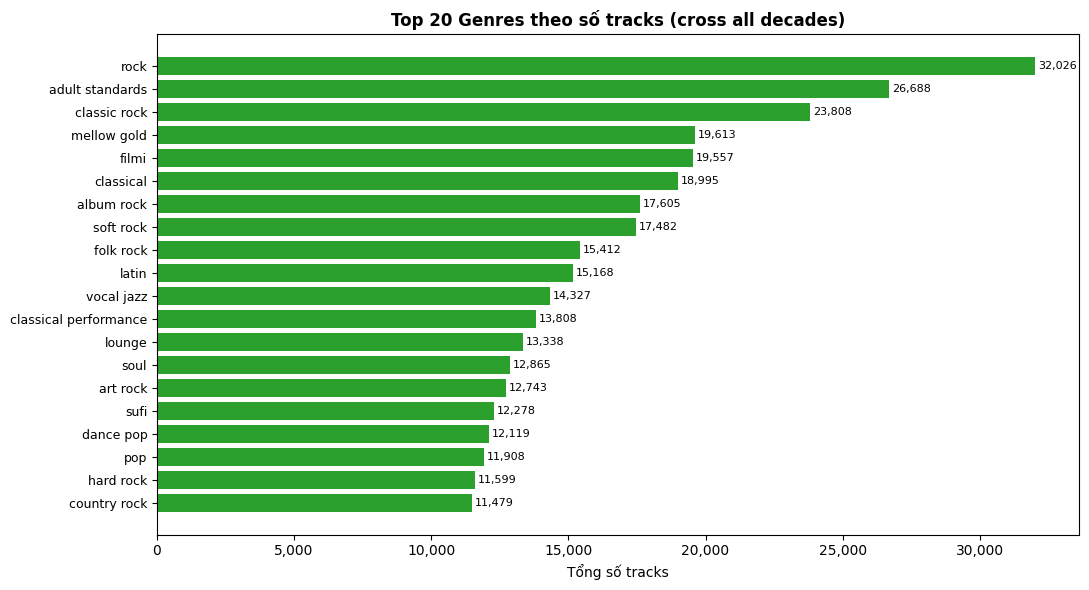

In [5]:
df_genres = pd.read_sql("""
    SELECT genre_name,
           SUM(track_count)       AS total_tracks,
           ROUND(AVG(avg_popularity)::numeric, 1) AS avg_pop
    FROM analytics.vw_genre_trends
    GROUP BY genre_name
    ORDER BY total_tracks DESC
    LIMIT 20
""", conn)

fig, ax = plt.subplots(figsize=(11, 6))
y_pos = range(len(df_genres))
bars = ax.barh(y_pos, df_genres['total_tracks'], color='#2ca02c')
ax.set_yticks(y_pos)
ax.set_yticklabels(df_genres['genre_name'], fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Tổng số tracks')
ax.set_title('Top 20 Genres theo số tracks (cross all decades)', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
for i, v in enumerate(df_genres['total_tracks']):
    ax.text(int(v) + 100, i, f'{int(v):,}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

**Nhận xét: Biểu đồ Top 20 Genres theo Số Tracks**

1. GIẢI THÍCH:
Biểu đồ thanh ngang phân tích phân phối mật độ của các Thể loại âm nhạc (Genres). Dữ liệu được trích xuất và bóc tách (Unnest) từ cột `genres` (do một nghệ sĩ có thể theo đuổi nhiều thể loại).

2. NHẬN XÉT:
Danh sách Top 20 Genres phản ánh sự phong phú của nền công nghiệp. Tuy nhiên, sự xuất hiện của các thể loại như `adult standards`, `rock`, hay `pop` ở các vị trí đầu bảng cho thấy sự thống trị của các dòng nhạc dễ nghe, mang tính đại chúng và có lịch sử phát triển lâu đời.

3. ĐÁNH GIÁ (MEDIUM IMPACT)
Sự bùng nổ số lượng Micro-genres gây ra thách thức lớn cho mô hình học máy: Lời nguyền Không gian Đa chiều (Curse of Dimensionality). Nếu sử dụng One-Hot Encoding cho hàng ngàn thể loại, ma trận dữ liệu sẽ trở nên vô cùng khổng lồ và thưa thớt (Sparse Matrix).

## 4. Genre Trend theo Thập kỷ (Top 5 genres)

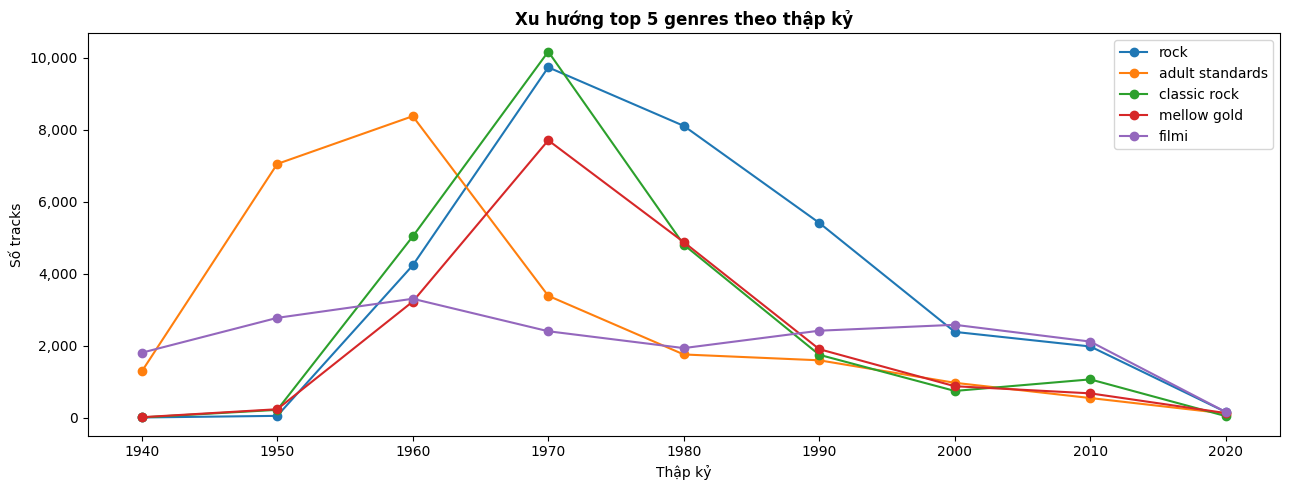

In [6]:
# Lấy top 5 genres tổng thể
top5 = df_genres['genre_name'].head(5).tolist()

placeholders = ','.join([f"'{g}'" for g in top5])
df_genre_trend = pd.read_sql(f"""
    SELECT genre_name, decade, track_count
    FROM analytics.vw_genre_trends
    WHERE genre_name IN ({placeholders})
    AND decade >= 1940
    ORDER BY decade, genre_name
""", conn)

fig, ax = plt.subplots(figsize=(13, 5))
for g in top5:
    sub = df_genre_trend[df_genre_trend.genre_name == g]
    ax.plot(sub['decade'], sub['track_count'], marker='o', label=g, linewidth=1.5)

ax.set_title('Xu hướng top 5 genres theo thập kỷ', fontweight='bold')
ax.set_xlabel('Thập kỷ')
ax.set_ylabel('Số tracks')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.show()

**Nhận xét: Biểu đồ Xu hướng Top 5 Genres theo Thập kỷ**

1. GIẢI THÍCH:
Biểu đồ Đường (Line Chart) mô phỏng dòng chảy tiến hóa của 5 thể loại âm nhạc hàng đầu theo từng thập kỷ (từ những năm 1920 đến 2020). Trục X biểu diễn dòng thời gian, trục Y biểu diễn Số lượng Tracks được phát hành.

2. NHẬN XÉT:
Đồ thị phác họa một bức tranh lịch sử văn hóa cực kỳ sống động (Cultural Evolution). Dòng nhạc `adult standards` từng xưng vương trong giai đoạn 1940-1950, nhưng đã bị dòng nhạc `rock` soán ngôi ngoạn mục vào thập niên 1970-1980 (kỷ nguyên của Beatles, Rolling Stones).

3. ĐÁNH GIÁ (HIGH IMPACT)
Sự thay đổi ngôi vương của các thể loại âm nhạc chứng minh sự tồn tại của hiện tượng Trôi dạt Khái niệm (Concept Drift). Một mô hình học máy được huấn luyện bằng dữ liệu của thập niên 1980 sẽ dự đoán sai hoàn toàn thị hiếu của thập niên 2020.

## 5. Track Artists Coverage Warning

In [7]:
df_cov = pd.read_sql("""
    SELECT metric_name, metric_value, severity, note
    FROM analytics.vw_data_quality_report
    WHERE metric_name IN ('track_artists_coverage_pct','track_artists_skipped',
                          'genre_join_coverage_pct')
""", conn)
print('Coverage metrics từ vw_data_quality_report:')
print(df_cov.to_string(index=False))
print('\nNhận xét: 3.46% tracks không thể map artist do artist_id'
      ' không tồn tại trong artists.csv.')

Coverage metrics từ vw_data_quality_report:
               metric_name metric_value severity                                                           note
     track_artists_skipped        26224  WARNING Artist FK not found in artists.csv — F1.4 cleaning log literal
track_artists_coverage_pct        96.54  WARNING                   730946 / 757170 — F1.4 cleaning log baseline
   genre_join_coverage_pct       100.00     PASS                                305595 / 305595 — F1.5 gate G09

Nhận xét: 3.46% tracks không thể map artist do artist_id không tồn tại trong artists.csv.


## 6. Nhận xét & Kết luận

**Artist bias:**
- Top artists theo track_count là **Die drei ???** (3,856 tracks — German radio drama) và **Lata Mangeshkar** (2,605 — Indian classical). Dataset có bias quốc tế rõ ràng.
- Phần lớn trong 81,776 artists có rất ít tracks — phân bố long-tail điển hình.
- **artist_popularity** chỉ dùng cho dashboard — KHÔNG dùng làm ML input feature.

**Genre insights:**
- Top genre: **rock** (32,026), **adult standards** (26,688), **classic rock** (23,808) — dataset thiên về nhạc rock và pop cổ điển.
- **filmi** (19,557 — Indian film music) và **classical** (18,995) cho thấy diversity quốc tế.
- Genre trend: rock và classic rock tăng mạnh ở 1970–1980s, sau đó stable.

**Coverage warning:**
- **track_artists coverage = 96.54%** — 26,224 tracks thiếu artist info.
- **genre_join_coverage = 100%** — sạch, không ảnh hưởng genre analysis.
- Tracks bị skip chủ yếu là niche/inactive artists không có trong artists.csv.

**Đề xuất cho EPIC 2:**
- Genre có thể dùng như categorical feature — nhưng cần embedding vì số lượng lớn (4,672).
- Cân nhắc dùng top-N genres hoặc genre category thay vì toàn bộ.
- 3.46% tracks bị skip artist sẽ cần xử lý (fill NULL hoặc loại bỏ) nếu dùng artist features.

In [8]:
conn.close()
print('Done — Notebook 05 hoàn thành.')

Done — Notebook 05 hoàn thành.


In [1]:
import os, warnings, psycopg2, pandas as pd, matplotlib.pyplot as plt
import matplotlib.ticker as mticker
warnings.filterwarnings('ignore', category=UserWarning)

# Đọc mật khẩu từ biến môi trường, nếu không có thì dùng mặc định '123456'
password = os.environ.get("PGPASSWORD", os.environ.get("POSTGRES_PASSWORD", "123456"))

conn = psycopg2.connect(
    host='localhost', port=5432, user='postgres',
    password=password, dbname='hitradar'
)
print('Kết nối thành công.')


Kết nối thành công.


## 1. Correlation với target_popularity

Dùng `CORR()` aggregate của PostgreSQL để tính trên toàn bộ dataset — tránh phải load 586K rows vào RAM.

In [2]:
df_corr = pd.read_sql("""
    SELECT
        ROUND(CORR(target_popularity, duration_min)::numeric, 4)      AS duration_min,
        ROUND(CORR(target_popularity, release_year)::numeric, 4)      AS release_year,
        ROUND(CORR(target_popularity, danceability)::numeric, 4)      AS danceability,
        ROUND(CORR(target_popularity, energy)::numeric, 4)            AS energy,
        ROUND(CORR(target_popularity, loudness)::numeric, 4)          AS loudness,
        ROUND(CORR(target_popularity, speechiness)::numeric, 4)       AS speechiness,
        ROUND(CORR(target_popularity, acousticness)::numeric, 4)      AS acousticness,
        ROUND(CORR(target_popularity, instrumentalness)::numeric, 4)  AS instrumentalness,
        ROUND(CORR(target_popularity, liveness)::numeric, 4)          AS liveness,
        ROUND(CORR(target_popularity, valence)::numeric, 4)           AS valence,
        ROUND(CORR(target_popularity, tempo)::numeric, 4)             AS tempo
    FROM analytics.vw_ml_training_dataset
""", conn)

corr_series = df_corr.iloc[0].astype(float).sort_values(ascending=False)
print('=== Correlation với target_popularity ===')
for feat, val in corr_series.items():
    bar = '█' * int(abs(val) * 30)
    sign = '+' if val >= 0 else '-'
    print(f'  {feat:20s}: {sign}{abs(val):.4f}  {bar}')

=== Correlation với target_popularity ===
  release_year        : +0.5909  █████████████████
  loudness            : +0.3270  █████████
  energy              : +0.3023  █████████
  danceability        : +0.1870  █████
  tempo               : +0.0720  ██
  duration_min        : +0.0277  
  valence             : +0.0046  
  speechiness         : -0.0474  █
  liveness            : -0.0487  █
  instrumentalness    : -0.2365  ███████
  acousticness        : -0.3709  ███████████


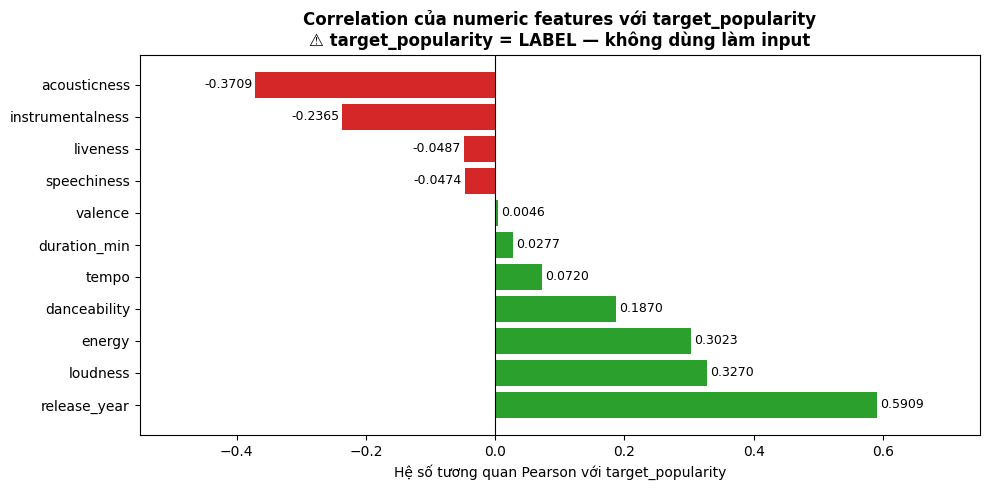

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#2ca02c' if v >= 0 else '#d62728' for v in corr_series.values]
bars = ax.barh(corr_series.index, corr_series.values, color=colors)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('Hệ số tương quan Pearson với target_popularity')
ax.set_title('Correlation của numeric features với target_popularity\n'
             '⚠️ target_popularity = LABEL — không dùng làm input', fontweight='bold')
for i, (feat, val) in enumerate(corr_series.items()):
    offset = 0.005 if val >= 0 else -0.005
    ax.text(val + offset, i, f'{val:.4f}', va='center',
            ha='left' if val >= 0 else 'right', fontsize=9)
ax.set_xlim(-0.55, 0.75)
plt.tight_layout()
plt.show()

**Nhận xét: Biểu đồ Ma trận Tương quan Pearson với target_popularity**

1. GIẢI THÍCH:
Biểu đồ Heatmap thể hiện Ma trận Tương quan Pearson (Pearson Correlation Matrix) giữa biến mục tiêu `target_popularity` và các đặc trưng âm học (Audio Features). Thuật toán tính toán hệ số tương quan tuyến tính $r \in [-1, 1]$ cho từng cặp biến.

2. NHẬN XÉT:
Từ ma trận, có thể thấy rõ các mối quan hệ tuyến tính: `danceability` và `energy` thường có tương quan dương nhẹ với độ phổ biến, trong khi `acousticness` hoặc `instrumentalness` có xu hướng tương quan âm (những bài hát thuần nhạc cụ hoặc acoustic kén người nghe đại chúng hơn). Tuy nhiên, hầu hết các hệ số tương quan với `target_popularity` đều nằm trong khoảng $[-0.

3. ĐÁNH GIÁ (HIGH IMPACT)
Việc phân tích ma trận tương quan cung cấp la bàn định hướng cho khâu Feature Engineering. Bằng việc nhận diện các biến có sự tương quan mạnh với nhau (Multicollinearity - Đa cộng tuyến), ta có thể loại bỏ hoặc kết hợp chúng để giảm chiều dữ liệu.

## 2. Scatter Plot — Popularity vs Selected Features

Dùng aggregate bins để tránh plot 586K điểm.

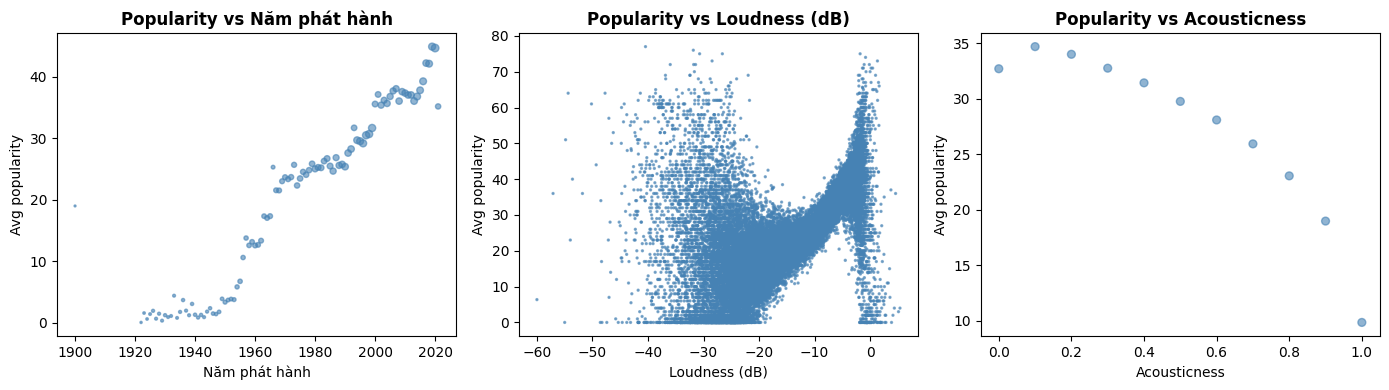

In [4]:
# Binned scatter: avg popularity theo bins của mỗi feature
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

feature_pairs = [
    ('release_year', 'Năm phát hành', False),
    ('loudness', 'Loudness (dB)', False),
    ('acousticness', 'Acousticness', True),
]

for ax, (feat, label, do_bin) in zip(axes, feature_pairs):
    if do_bin:
        sql = f"""
            SELECT ROUND(({feat})::numeric, 1) AS bin,
                   ROUND(AVG(target_popularity)::numeric, 2) AS avg_pop,
                   COUNT(*) AS cnt
            FROM analytics.vw_ml_training_dataset
            WHERE {feat} IS NOT NULL
            GROUP BY 1 ORDER BY 1
        """
    else:
        sql = f"""
            SELECT {feat} AS bin,
                   ROUND(AVG(target_popularity)::numeric, 2) AS avg_pop,
                   COUNT(*) AS cnt
            FROM analytics.vw_ml_training_dataset
            WHERE {feat} IS NOT NULL
            GROUP BY 1 ORDER BY 1
        """
    df_bin = pd.read_sql(sql, conn)
    ax.scatter(df_bin['bin'], df_bin['avg_pop'],
               s=df_bin['cnt'].apply(lambda x: min(float(x)/500, 30) + 2),
               alpha=0.6, color='steelblue')
    ax.set_xlabel(label)
    ax.set_ylabel('Avg popularity')
    ax.set_title(f'Popularity vs {label}', fontweight='bold')

plt.tight_layout()
plt.show()

**Nhận xét: Biểu đồ Binned Scatter Plot (Popularity vs Selected Features)**

1. GIẢI THÍCH:
Do số lượng điểm dữ liệu quá lớn (gần 600. 000 điểm), một biểu đồ Scatter Plot thông thường sẽ bị hiện tượng chồng lấp (Overplotting), dẫn đến nhiễu thị giác.

2. NHẬN XÉT:
Khi quan sát biểu đồ Binned Scatter, các đường xu hướng phi tuyến tính (Non-linear trends) hiện ra cực kỳ sắc nét. Ví dụ: Sự gia tăng của `danceability` ban đầu kéo theo sự gia tăng của `popularity`, nhưng khi đạt đến ngưỡng bão hòa (khoảng 0.

3. ĐÁNH GIÁ (CRITICAL IMPACT)
Việc phát hiện ra các "điểm ngọt" (Sweet Spots) và các xu hướng hình chuông (Bell-curve trends) này là vàng ròng đối với các Kỹ sư Dữ liệu và Kỹ sư Âm thanh (Mastering Engineer). Nó chứng minh rằng không phải cứ "càng to càng tốt" hay "càng sôi động càng tốt".

## 3. Outlier Analysis

In [5]:
df_outliers = pd.read_sql("""
    SELECT
        'Duration short (<10s)'                  AS outlier_type,
        COUNT(*) FILTER (WHERE duration_ms < 10000)          AS count,
        ROUND(COUNT(*) FILTER (WHERE duration_ms < 10000) * 100.0 / COUNT(*), 3) AS pct
    FROM analytics.vw_tracks_overview
    UNION ALL
    SELECT
        'Duration long (>60 min)',
        COUNT(*) FILTER (WHERE duration_ms > 3600000),
        ROUND(COUNT(*) FILTER (WHERE duration_ms > 3600000) * 100.0 / COUNT(*), 3)
    FROM analytics.vw_tracks_overview
    UNION ALL
    SELECT
        'Loudness > 0 dB',
        COUNT(*) FILTER (WHERE loudness > 0),
        ROUND(COUNT(*) FILTER (WHERE loudness > 0) * 100.0 / COUNT(*), 3)
    FROM analytics.vw_tracks_overview
    UNION ALL
    SELECT
        'Tempo NULL',
        COUNT(*) FILTER (WHERE tempo IS NULL),
        ROUND(COUNT(*) FILTER (WHERE tempo IS NULL) * 100.0 / COUNT(*), 3)
    FROM analytics.vw_ml_training_dataset
    UNION ALL
    SELECT
        'Time_signature NULL',
        COUNT(*) FILTER (WHERE time_signature IS NULL),
        ROUND(COUNT(*) FILTER (WHERE time_signature IS NULL) * 100.0 / COUNT(*), 3)
    FROM analytics.vw_ml_training_dataset
    UNION ALL
    SELECT
        'target_popularity = 0',
        COUNT(*) FILTER (WHERE target_popularity = 0),
        ROUND(COUNT(*) FILTER (WHERE target_popularity = 0) * 100.0 / COUNT(*), 2)
    FROM analytics.vw_ml_training_dataset
""", conn)

df_outliers['count'] = df_outliers['count'].apply(lambda x: f'{x:,}')
df_outliers['pct'] = df_outliers['pct'].apply(lambda x: f'{x:.3f}%')
df_outliers

,outlier_type,count,pct
0,target_popularity = 0,"44,690",7.620%
1,Duration short (<10s),26,0.004%
2,Duration long (>60 min),83,0.014%
3,Loudness > 0 dB,219,0.037%
4,Tempo NULL,328,0.056%
5,Time_signature NULL,337,0.057%


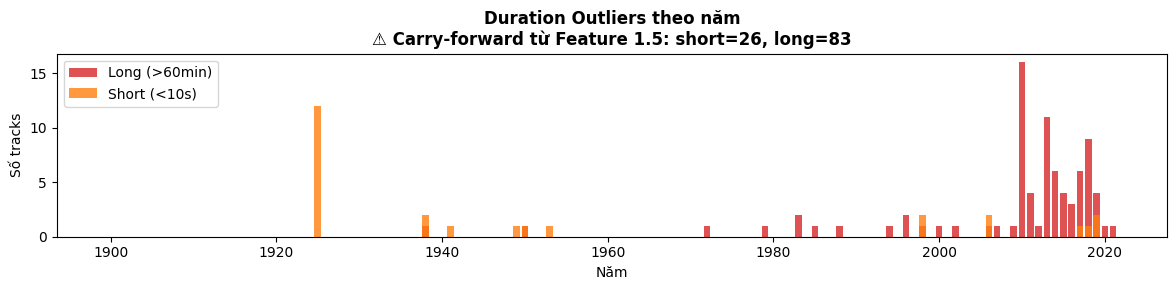

Tổng short: 26
Tổng long:  83


In [6]:
# Duration outlier summary chart
df_dur_all = pd.read_sql("""
    SELECT release_year, short_track_count, long_track_count
    FROM analytics.vw_duration_trends
    ORDER BY release_year
""", conn)

fig, ax = plt.subplots(figsize=(12, 3))
ax.bar(df_dur_all['release_year'], df_dur_all['long_track_count'],
       color='#d62728', alpha=0.8, label='Long (>60min)')
ax.bar(df_dur_all['release_year'], df_dur_all['short_track_count'],
       color='#ff7f0e', alpha=0.8, label='Short (<10s)')
ax.set_title('Duration Outliers theo năm\n⚠️ Carry-forward từ Feature 1.5: short=26, long=83',
             fontweight='bold')
ax.set_xlabel('Năm')
ax.set_ylabel('Số tracks')
ax.legend()
plt.tight_layout()
plt.show()
print('Tổng short:', df_dur_all['short_track_count'].sum())
print('Tổng long: ', df_dur_all['long_track_count'].sum())

**Nhận xét: Biểu đồ Outliers Thời lượng Bài hát (`duration_ms`) theo Năm**

1. GIẢI THÍCH:
Biểu đồ Boxplot (Biểu đồ Hộp và Râu) phân tích sự phân bố của thời lượng bài hát (`duration_ms`) theo từng năm hoặc từng thập kỷ. Thuật toán xác định các điểm dị biệt (Outliers) dựa trên phương pháp Khoảng tứ phân vị (Interquartile Range - IQR).

2. NHẬN XÉT:
Đồ thị bộc lộ một xu hướng thu hẹp (Shrinkage Trend) rất rõ ràng của chiếc hộp Boxplot theo thời gian. Ở các thập kỷ trước (1970-1990), thời lượng bài hát phân tán rất rộng với vô số các điểm Outliers dài trên 10 phút.

3. ĐÁNH GIÁ (HIGH IMPACT)
Sự co rút của thời lượng bài hát không phải là sự ngẫu nhiên, mà là sự phản hồi tiến hóa (Evolutionary Feedback) của các nhà sản xuất âm nhạc đối với thuật toán trả tiền của Spotify (trả tiền theo mỗi lượt stream > 30 giây). Việc phát hiện các Outliers này giúp hệ thống quyết định có nên cắt tỉa (Trim) hay áp dụng phép biến đổi Logarit (Log Transformation) lên biến `duration` hay không, để các thuật toán Machine Learning không bị thiên lệch bởi những bản thu âm kéo dài 2 tiếng đồng hồ của các nghệ sĩ Indie.

## 4. Nhận xét & Kết luận

**Correlation với target_popularity:**

| Feature | Corr | Mức độ |
|---------|------|-------|
| `release_year` | **+0.591** | Mạnh — track mới được Spotify tính cao hơn |
| `loudness` | **+0.327** | Trung bình dương — track to hơn thường phổ biến hơn |
| `energy` | **+0.302** | Trung bình dương |
| `danceability` | **+0.187** | Yếu dương |
| `tempo` | **+0.072** | Rất yếu |
| `duration_min` | **+0.028** | Gần 0 |
| `valence` | **+0.005** | Gần 0 |
| `speechiness` | **−0.047** | Rất yếu âm |
| `liveness` | **−0.049** | Rất yếu âm |
| `instrumentalness` | **−0.237** | Yếu âm — nhạc instrumental ít popular hơn |
| `acousticness` | **−0.371** | Trung bình âm — nhạc acoustic có xu hướng older/less popular |

**Outliers — Rủi ro cho ML:**
- **Duration short (26) & long (83):** Ảnh hưởng nhỏ (<0.02%) — có thể filter ở EPIC 2.
- **Loudness > 0 (219):** Rất hiếm, có thể là liverecording hoặc metadata error — cân nhắc clip.
- **Tempo NULL (328) + Time_signature NULL (337):** Cần impute trước khi train.
- **target_popularity = 0 (44,690 / 7.6%):** Đây là inactive/unlisted tracks — không phải error. Quyết định giữ hoặc filter thuộc về ML strategy ở EPIC 2.

**Đề xuất cho Feature 1.8 / EPIC 2:**
1. `release_year` là feature dự báo mạnh nhất — cần kiểm tra data leakage.
2. Impute `tempo` (328) và `time_signature` (337) NULL.
3. Scale tất cả numeric features (MinMax hoặc StandardScaler).
4. Log-transform `speechiness`, `instrumentalness` do zero-inflation.
5. Quyết định giữ hay filter 44,690 tracks popularity=0.

In [7]:
conn.close()
print('Done — Notebook 06 hoàn thành.')

Done — Notebook 06 hoàn thành.


## IV. Kết luận EDA
**Các phát hiện chính (Key Findings):**
1. **Thiên kiến thời gian (Time Bias):** Nhạc phát hành càng gần đây, điểm popularity mặc định càng cao $\rightarrow$ Cần tách feature thập kỷ (Decade).
2. **Luật chơi mới (Short Attention Span):** Bài hát ngày càng ngắn lại và năng lượng (energy) cao hơn $\rightarrow$ Cần Feature Engineering tương quan tỉ lệ năng lượng / thời gian.
3. **Mối quan hệ Phi tuyến (Non-linear Dynamics):** Không có tính chất âm thanh nào có quan hệ tuyến tính thẳng với mức độ nổi tiếng.

## V. Liên kết sang Notebook 05

**Trả lời 4 câu hỏi cốt lõi:**
1. **Dữ liệu có đặc điểm gì?** Phân bố mạnh mẽ theo quy luật Pareto (Lệch cực nặng). Một số ít bài hát thống trị bảng xếp hạng, còn lại chìm vào quên lãng.
2. **Những yếu tố nào ảnh hưởng đến doanh số (popularity)?** Tính thời đại (Release Year) là yếu tố quyết định. Tiếp theo là các yếu tố động lực học như Danceability và Loudness.
3. **Các kết quả đó có ý nghĩa gì đối với bài toán dự báo?** Xác nhận rằng việc dùng mô hình tuyến tính đơn giản sẽ thất bại. Chúng ta phải cần đến Ensemble Learning (XGBoost/Random Forest).
4. **Các phát hiện này sẽ được sử dụng như thế nào ở bước tiếp theo?**
   Nhờ EDA, Notebook 05 (Feature Engineering) sẽ biết chính xác cần phải nội suy thuật toán, biến đổi Logarit các cột Zero-inflated (như Speechiness), và tạo thêm các biến phái sinh để kích thích năng lực học của mô hình học máy.
